In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.animation as animation
import matplotlib.cm as cm
from matplotlib.patches import Rectangle
from tqdm import tqdm
from PIL import Image
import os
import gc
import warnings
from funcs import *
import cupy as cp

def _to_numpy(array):
    """Convert a NumPy/CuPy-compatible array to a NumPy array for plotting."""
    return cp.asnumpy(array) if isinstance(array, cp.ndarray) else np.asarray(array)

%matplotlib inline
warnings.filterwarnings('ignore')

# Shared court grid used by bin_and_flip and the synthetic effect maps.
x_bins = 20
y_bins = 10

# Synthetic Threat-Profile Construction

This notebook is a recovery experiment: it defines a known spatial scoring pattern, generates synthetic possession outcomes from that pattern, and then asks the total-variation (TV) logistic/QUT pipeline to reconstruct the pattern from the simulated data.

## End-to-end workflow

1. Load cleaned, half-court-filtered ball-tracking observations.
2. Discretize court coordinates into a shared `20 × 10` grid. A sector is represented by `(x_bin, y_bin)`. Section 5 explicitly enables the home/away, half, and game-level orientation rotations.
3. Sample complete possessions from six training games and summarize which sectors each possession visited.
4. Apply manually specified movement and end-location effects to a baseline scoring probability.
5. Draw one Bernoulli outcome per possession using the resulting probability.
6. Replace the observed scoring label with the simulated label and retain only the four columns required by QUT.
7. Run `analyze_tv_logistic_single_game` on the simulated data and compare its estimated spatial profile with the known input profile.

The training games are `21500649`, `21500390`, `21500188`, `21500355`, `21500057`, and `21500009`. All simulations use the same games and model settings but different spatial effects and random seeds.

## Important conventions

- Effect arrays have shape `(x_bins, y_bins)` and are indexed as `effects[x_bin, y_bin]`.
- Plotting uses `effect.T` because image rows correspond to the vertical/y axis.
- Effects are **additive changes to probability**, not log-odds: `p = clip(baseline + movement + end, 0, 1)`.
- Movement effects are summed over the sectors represented in the possession summary. If a weight column is supplied, each sector effect is multiplied by that weight first.
- End effects contribute only for the possession's final sector.
- All planted surfaces are defined once in Section 0. Profile experiment cells load independent copies into the reusable `pipeline_*` working names.

## 0. Define the planted profiles

All spatial profiles are defined here, before any tracking data is loaded. Run only the import cell and this cell to construct or edit the profile arrays. Later experiment cells copy their selected arrays from `simulation_profiles`, so running one profile can no longer overwrite another.

In [11]:
SIMULATION_TRAIN_GAMES = (21500649, 21500390, 21500188, 21500355, 21500057, 21500009)
train_set = list(SIMULATION_TRAIN_GAMES)

# Profile 1: reference court pattern.
reference_movement_effects = np.zeros((x_bins, y_bins))
reference_end_effects = np.zeros((x_bins, y_bins))
reference_movement_effects[10:18, 0:3] = .05
reference_movement_effects[18:20, 0:3] = .05
reference_movement_effects[18:20, 6] = .05
reference_movement_effects[10:20, 6:10] = .05
reference_movement_effects[18:20, 2:6] = .05
reference_movement_effects[10:18, 2:6] = 0
reference_movement_effects[10:12, 6:8] = 0
reference_movement_effects[10:13, :] = 0
reference_movement_effects[18:20, 2:4] = .05

# Profile 2: emphasize the high-y side of the offensive half.
high_y_side_movement_effects = np.zeros((x_bins, y_bins))
high_y_side_end_effects = np.zeros((x_bins, y_bins))
high_y_side_movement_effects[13:20, 5:10] = .05

# Profile 3: emphasize the low-y side of the offensive half.
low_y_side_movement_effects = np.zeros((x_bins, y_bins))
low_y_side_end_effects = np.zeros((x_bins, y_bins))
low_y_side_movement_effects[13:20, 0:5] = .05

# Profile 4: stepped perimeter-like signal with an interior penalty.
perimeter_movement_effects = np.zeros((x_bins, y_bins))
perimeter_end_effects = np.zeros((x_bins, y_bins))
perimeter_movement_effects[15:20, 9] = .05
perimeter_movement_effects[14:18, 8:10] = .05
perimeter_movement_effects[14:16, 7:9] = .05
perimeter_movement_effects[13:15, 3:7] = .05
perimeter_movement_effects[14:20, 0] = .05
perimeter_movement_effects[14:18, 1] = .05
perimeter_movement_effects[14:16, 2] = .05
perimeter_movement_effects[13, 0:10] = .05
perimeter_movement_effects[15:20, 3:7] = -.05
perimeter_movement_effects[18:20, 3:7] = -.05
perimeter_movement_effects[16:18, 3:7] = -.05
perimeter_movement_effects[15, 3:7] = 0

simulation_profiles = {
    "reference": {
        "label": "Reference court pattern",
        "movement_effects": reference_movement_effects,
        "end_effects": reference_end_effects,
        "seed": 42,
    },
    "high_y_side": {
        "label": "High-y-side emphasis",
        "movement_effects": high_y_side_movement_effects,
        "end_effects": high_y_side_end_effects,
        "seed": 43,
    },
    "low_y_side": {
        "label": "Low-y-side emphasis",
        "movement_effects": low_y_side_movement_effects,
        "end_effects": low_y_side_end_effects,
        "seed": 44,
    },
    "perimeter": {
        "label": "Stepped perimeter pattern",
        "movement_effects": perimeter_movement_effects,
        "end_effects": perimeter_end_effects,
        "seed": 45,
    },
}

pd.DataFrame([
    {"profile": name, "label": profile["label"], "seed": profile["seed"]}
    for name, profile in simulation_profiles.items()
])

,profile,label,seed
0,reference,Reference court pattern,42
1,high_y_side,High-y-side emphasis,43
2,low_y_side,Low-y-side emphasis,44
3,perimeter,Stepped perimeter pattern,45


## 1. Load and bin the tracking data

The input CSV must contain the identifiers and coordinates used by `bin_and_flip`, including `game_id`, `possession_number`, `period`, `is_home`, `x`, `y`, and `scored`. Each row is a tracking sample, so a possession normally appears in many rows.

`bin_and_flip` converts continuous coordinates to integer `x_bin` and `y_bin` values. In the current helper implementation, `flip="no"` performs the home/away, half, and game-level rotations, whereas `flip="yes"` skips those rotations. The preview and original Section 3 profile cells retain their existing `"yes"` setting; the pooled incremental experiment in Section 5 explicitly passes `flip="no"` because those rotations are required there. The `sector` tuple is then the stable key used by the simulation helpers. The displayed frames below are inspection checkpoints; they do not mutate the data.

In [12]:
# One row represents one tracking observation within a possession.
cleaned = pd.read_csv("multi_game_data/multi_game_data_half_court_filtered.csv")

In [13]:
cleaned

,game_id,home_away,is_home,period,time,x,y,z,source_possession_start,source_possession_end,possession_start,possession_end,ORIGINAL_POSSESSION_NUMBER,SOURCE_POSSESSION_NUMBER,possession_number,source_points_scored,points_scored,scored,contains_confirmed_continuation,half_court_crossings
0,21500009,home,1,1,719.00,37.04728,15.02163,6.44393,720,703,720,703,1,1,1,2,2,1,False,1
1,21500009,home,1,1,718.96,36.30142,14.70948,6.12091,720,703,720,703,1,1,1,2,2,1,False,1
2,21500009,home,1,1,718.92,35.67854,14.33637,5.70189,720,703,720,703,1,1,1,2,2,1,False,1
3,21500009,home,1,1,718.88,34.84530,13.68251,5.15255,720,703,720,703,1,1,1,2,2,1,False,1
4,21500009,home,1,1,718.84,34.18749,13.55080,4.64143,720,703,720,703,1,1,1,2,2,1,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283967,21500649,home,1,4,21.13,89.05357,25.22764,7.01554,34,21,34,21,175,86,84,2,2,1,False,1
283968,21500649,home,1,4,21.09,88.85823,25.43094,6.69550,34,21,34,21,175,86,84,2,2,1,False,1
283969,21500649,home,1,4,21.05,89.01390,25.20261,5.98559,34,21,34,21,175,86,84,2,2,1,False,1
283970,21500649,home,1,4,21.01,89.04044,25.37756,6.20067,34,21,34,21,175,86,84,2,2,1,False,1


In [14]:
# The prepared data already has the desired orientation; flip="yes" skips
# reorientation and discretizes the coordinates on the shared grid.
cleaned_binned = bin_and_flip(cleaned, flip="yes", x_bins=x_bins, y_bins=y_bins)
# Tuple keys make sector-level grouping and effect lookup explicit.
cleaned_binned["sector"] = list(zip(cleaned_binned["x_bin"], cleaned_binned["y_bin"]))
cleaned_binned

,game_id,home_away,is_home,period,time,x,y,z,source_possession_start,source_possession_end,...,SOURCE_POSSESSION_NUMBER,possession_number,source_points_scored,points_scored,scored,contains_confirmed_continuation,half_court_crossings,x_bin,y_bin,sector
0,21500009,home,1,1,719.00,37.04728,15.02163,6.44393,720,703,...,1,1,2,2,1,False,1,7,3,"(7, 3)"
1,21500009,home,1,1,718.96,36.30142,14.70948,6.12091,720,703,...,1,1,2,2,1,False,1,7,2,"(7, 2)"
2,21500009,home,1,1,718.92,35.67854,14.33637,5.70189,720,703,...,1,1,2,2,1,False,1,7,2,"(7, 2)"
3,21500009,home,1,1,718.88,34.84530,13.68251,5.15255,720,703,...,1,1,2,2,1,False,1,7,2,"(7, 2)"
4,21500009,home,1,1,718.84,34.18749,13.55080,4.64143,720,703,...,1,1,2,2,1,False,1,7,2,"(7, 2)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283967,21500649,home,1,4,21.13,89.05357,25.22764,7.01554,34,21,...,86,84,2,2,1,False,1,18,5,"(18, 5)"
283968,21500649,home,1,4,21.09,88.85823,25.43094,6.69550,34,21,...,86,84,2,2,1,False,1,18,5,"(18, 5)"
283969,21500649,home,1,4,21.05,89.01390,25.20261,5.98559,34,21,...,86,84,2,2,1,False,1,18,5,"(18, 5)"
283970,21500649,home,1,4,21.01,89.04044,25.37756,6.20067,34,21,...,86,84,2,2,1,False,1,18,5,"(18, 5)"


## 2. Possession summarization and simulation helpers

The helpers below form the reusable simulation layer:

- `build_visited_possessions` reduces tracking rows to one row per possession-sector pair and attaches visit duration/proportion, the possession outcome, the final-sector flag, and a recent-visit flag.
- `_sector_effect_lookup` safely reads an effect from either a dictionary or a NumPy/CuPy matrix. Out-of-grid sectors receive zero effect.
- `create_baseline_scoring_probabilities` aggregates sector effects to one scoring probability per possession.
- `plot_effect_surfaces` visualizes movement and end effects over the court image with one grid unit per bin.
- `sample_possessions_from_games` samples possession identifiers—not individual tracking rows—so each selected possession remains intact.
- `build_baseline_scoring_pipeline` composes sampling, binning, possession summarization, and probability construction, returning intermediate tables for inspection.

The misspelled key `visited_posssessions` is retained for compatibility with the existing profile cells.

In [15]:
possession_cols = ["game_id", "possession_number"]


def build_visited_possessions(
    binned_df,
    possession_cols=possession_cols,
    sector_col="sector",
    scored_col="scored",
    sample_interval_seconds=0.04,
    last_n_unique_visited=5,
):
    """Summarize tracking observations at the possession-sector level.

    Parameters
    ----------
    binned_df : pandas.DataFrame
        Tracking rows with possession identifiers, a sector tuple, and a
        possession-level scoring label repeated across the tracking rows.
    possession_cols : sequence of str
        Columns that jointly identify a possession.
    sector_col : str
        Column containing `(x_bin, y_bin)` tuples.
    scored_col : str
        Binary possession outcome. `max` is used to collapse repeated values.
    sample_interval_seconds : float
        Seconds represented by one tracking row; used to convert visit counts
        into approximate time spent in each sector.
    last_n_unique_visited : int
        Number of most recently visited distinct sectors to flag.

    Returns
    -------
    pandas.DataFrame
        One row per possession-sector pair. Besides identifiers and `count`,
        the result contains `time`, `time_proportion`, the scoring outcome,
        `is_end_sector`, and `was_last_<N>_visited`.

    Notes
    -----
    The end sector is taken from the last tracking row of each possession.
    Recent sectors are ordered by their last occurrence in the raw rows.
    """
    required_cols = set(possession_cols) | {sector_col, scored_col}
    missing_cols = required_cols.difference(binned_df.columns)
    if missing_cols:
        raise ValueError(f"binned_df is missing required columns: {sorted(missing_cols)}")

    visited = binned_df.groupby(possession_cols, observed=False)[sector_col].value_counts().reset_index()
    visited["time"] = visited["count"] * sample_interval_seconds
    visited["time_proportion"] = (
        visited["count"]
        / visited.groupby(possession_cols, observed=False)["count"].transform("sum")
    )

    possession_scoring = (
        binned_df.groupby(possession_cols, observed=False)[scored_col].max().reset_index()
    )
    visited = visited.merge(possession_scoring, on=possession_cols, how="left")

    end_sector = (
        binned_df.drop_duplicates(possession_cols, keep="last")
        .assign(is_end_sector=True)[possession_cols + [sector_col, "is_end_sector"]]
    )
    visited = visited.merge(end_sector, on=possession_cols + [sector_col], how="left")
    visited["is_end_sector"] = visited["is_end_sector"].eq(True)

    last_visited_col = f"was_last_{last_n_unique_visited}_visited"
    last_visited = (
        binned_df.drop_duplicates(possession_cols + [sector_col], keep="last")
        .groupby(possession_cols, observed=False)
        .tail(last_n_unique_visited)
        .assign(**{last_visited_col: True})[possession_cols + [sector_col, last_visited_col]]
    )
    visited = visited.merge(last_visited, on=possession_cols + [sector_col], how="left")
    visited[last_visited_col] = visited[last_visited_col].eq(True)

    return visited


def _sector_effect_lookup(sector, effects):
    """Return the effect assigned to one `(x_bin, y_bin)` sector.

    `effects` may be `None`, a dictionary keyed by sector tuples, or a 2-D
    NumPy/CuPy array indexed as `[x_bin, y_bin]`. Missing dictionary keys and
    coordinates outside the matrix bounds deliberately contribute `0.0`.
    CuPy scalars are copied back to the host and returned as Python floats.
    """
    if effects is None:
        return 0.0

    if isinstance(effects, dict):
        return effects.get(sector, 0.0)

    x_bin, y_bin = sector
    if 0 <= x_bin < effects.shape[0] and 0 <= y_bin < effects.shape[1]:
        if isinstance(effects, cp.ndarray):
            return float(effects[x_bin, y_bin].get())
        return effects[x_bin, y_bin]

    return 0.0


def create_baseline_scoring_probabilities(
    visited_possessions,
    movement_effects=None,
    end_effects=None,
    baseline_probability=None,
    possession_cols=("game_id", "possession_number"),
    sector_col="sector",
    movement_weight_col=None,
    end_indicator_col="is_end_sector",
    scored_col="scored",
):
    """Construct one additive scoring probability per possession.

    Parameters
    ----------
    visited_possessions : pandas.DataFrame
        Output of `build_visited_possessions` or an equivalent table with one
        row per possession-sector pair.
    movement_effects, end_effects : dict or array-like, optional
        Sector-level probability adjustments. Arrays must use shape
        `(x_bins, y_bins)` and `[x_bin, y_bin]` indexing.
    baseline_probability : float, optional
        Starting probability shared by all possessions. When omitted, it is
        estimated as the observed mean outcome across possessions.
    possession_cols : sequence of str
        Columns that jointly identify a possession.
    sector_col : str
        Column containing sector tuple keys.
    movement_weight_col : str, optional
        If provided, multiply each movement effect by this column before
        summing. Useful choices include `time` or `time_proportion`.
    end_indicator_col : str
        Boolean flag selecting the single final sector of a possession.
    scored_col : str
        Observed outcome column, retained in the returned diagnostic table.

    Returns
    -------
    pandas.DataFrame
        One row per possession with baseline, movement, and end components;
        the unclipped total; the final probability clipped to `[0, 1]`; and,
        when available, the observed scoring label.

    Notes
    -----
    This is an additive probability model, not a logistic transformation:
    `p = clip(p0 + sum(movement effects) + final-sector effect, 0, 1)`.
    With no `movement_weight_col`, a sector contributes once because the input
    table has already been collapsed to unique possession-sector pairs.
    """
    required_cols = set(possession_cols) | {sector_col}
    if movement_weight_col is not None:
        required_cols.add(movement_weight_col)
    missing_cols = required_cols.difference(visited_possessions.columns)
    if missing_cols:
        raise ValueError(f"visited_possessions is missing required columns: {sorted(missing_cols)}")

    df = visited_possessions.copy()

    if baseline_probability is None:
        if scored_col not in df.columns:
            raise ValueError("Provide baseline_probability or include a scored column.")
        baseline_probability = df.groupby(list(possession_cols), observed=False)[scored_col].max().mean()

    baseline_probability = np.clip(baseline_probability, 0, 1)
    df["movement_sector_effect"] = df[sector_col].apply(
        lambda sector: _sector_effect_lookup(sector, movement_effects)
    )
    if movement_weight_col is None:
        df["movement_probability_adjustment"] = df["movement_sector_effect"]
    else:
        df["movement_probability_adjustment"] = df["movement_sector_effect"] * df[movement_weight_col]

    if end_indicator_col in df.columns:
        df["end_sector_effect"] = df[sector_col].apply(
            lambda sector: _sector_effect_lookup(sector, end_effects)
        )
        df["end_probability_adjustment"] = np.where(df[end_indicator_col], df["end_sector_effect"], 0.0)
    else:
        df["end_probability_adjustment"] = 0.0

    probability_components = (
        df.groupby(list(possession_cols), observed=False)
        .agg(
            movement_probability_adjustment=("movement_probability_adjustment", "sum"),
            end_probability_adjustment=("end_probability_adjustment", "sum"),
        )
        .reset_index()
    )

    probability_components["movement_probability_adjustment"] = (
        probability_components["movement_probability_adjustment"].round(10)
    )
    probability_components["baseline_probability"] = baseline_probability
    probability_components["raw_scoring_probability"] = (
        probability_components["baseline_probability"]
        + probability_components["movement_probability_adjustment"]
        + probability_components["end_probability_adjustment"]
    )
    probability_components["scoring_probability"] = probability_components["raw_scoring_probability"].clip(0, 1)

    if scored_col in df.columns:
        actual_scoring = df.groupby(list(possession_cols), observed=False)[scored_col].max().reset_index()
        probability_components = probability_components.merge(actual_scoring, on=list(possession_cols), how="left")

    return probability_components


def plot_effect_surfaces(
    movement_effects,
    end_effects,
    court_image_path="court.jpg",
    x_bins=x_bins,
    y_bins=y_bins,
    title_prefix="Pipeline",
):
    """Plot movement and final-sector effect matrices over a court image.

    Both inputs must describe the same `(x_bins, y_bins)` grid. The matrices
    are transposed for display so x runs horizontally and y vertically. A
    shared symmetric color scale is used, making positive and negative effects
    directly comparable across the two panels. Set `court_image_path=None` to
    plot the effect grids without a background image.

    Returns
    -------
    None
        Displays a Matplotlib figure as a side effect.
    """
    effect_maps = [_to_numpy(movement_effects), _to_numpy(end_effects)]
    titles = [f"{title_prefix} Movement Effects", f"{title_prefix} End Effects"]
    v_abs = max(float(np.nanmax(np.abs(effect))) for effect in effect_maps)
    v_abs = v_abs if v_abs > 0 else 1.0

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
    court = Image.open(court_image_path) if court_image_path is not None else None

    for ax, effect, title in zip(axes, effect_maps, titles):
        if court is not None:
            ax.imshow(court, extent=[0, x_bins, 0, y_bins], aspect="auto")

        im = ax.imshow(
            effect.T,
            origin="lower",
            extent=[0, x_bins, 0, y_bins],
            cmap="coolwarm",
            alpha=0.75,
            vmin=-v_abs,
            vmax=v_abs,
        )

        for x in range(x_bins + 1):
            ax.axvline(x, color="white", lw=0.5, alpha=0.35)
        for y in range(y_bins + 1):
            ax.axhline(y, color="white", lw=0.5, alpha=0.35)

        ax.set_xlim(0, x_bins)
        ax.set_ylim(0, y_bins)
        ax.set_title(title)
        ax.set_xlabel("x_bin")
        ax.set_ylabel("y_bin")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Probability Adjustment")

    plt.show()


def sample_possessions_from_games(
    df,
    game_ids,
    n_possessions,
    possession_cols=possession_cols,
    random_state=None,
    reindex_possessions=True,
):
    """Sample complete possessions from a selected collection of games.

    Sampling is performed on unique possession keys and then joined back to all
    tracking rows. Sampling switches to replacement only when `n_possessions`
    exceeds the number of available possession keys. When reindexing is on,
    sampled possessions receive identifiers `0..n_possessions-1`, while the
    source identifier is retained in `original_possession_number`. This also
    keeps repeated draws distinct when sampling with replacement.

    Returns
    -------
    pandas.DataFrame
        All tracking rows belonging to the sampled possession draws.
    """
    game_col, possession_col = possession_cols
    game_df = df[df[game_col].isin(game_ids)].copy()
    possession_keys = game_df[possession_cols].drop_duplicates()

    if possession_keys.empty:
        raise ValueError("No possessions found for the requested game_ids.")

    replace = n_possessions > len(possession_keys)
    sampled_keys = possession_keys.sample(
        n=n_possessions,
        replace=replace,
        random_state=random_state,
    ).reset_index(drop=True)

    if reindex_possessions:
        sampled_keys = sampled_keys.assign(_sample_possession_number=lambda x: x.index)
        sampled = sampled_keys.merge(game_df, on=possession_cols, how="left")
        sampled["original_possession_number"] = sampled[possession_col]
        sampled[possession_col] = sampled["_sample_possession_number"]
        return sampled.drop(columns="_sample_possession_number")

    return game_df.merge(sampled_keys, on=possession_cols, how="inner")


def build_baseline_scoring_pipeline(
    df,
    train_games,
    n_possessions,
    movement_effects=None,
    end_effects=None,
    baseline_probability=0.50,
    random_state=None,
    flip="no",
    movement_weight_col=None,
    reindex_possessions=True,
):
    """Run the preprocessing portion of the synthetic-outcome pipeline.

    The function samples complete possessions, bins (and optionally reorients)
    their tracking coordinates with `bin_and_flip`, builds `(x_bin, y_bin)`
    sector keys,
    summarizes sector visits, and calculates one scoring probability per
    sampled possession. It does not draw Bernoulli outcomes or run QUT; those
    steps remain explicit in each profile cell below.

    Parameters
    ----------
    df : pandas.DataFrame
        Cleaned tracking observations.
    train_games : iterable
        Game IDs eligible for possession sampling.
    n_possessions : int
        Number of complete possession draws.
    movement_effects, end_effects : dict or array-like, optional
        Spatial probability adjustments passed to
        `create_baseline_scoring_probabilities`.
    baseline_probability : float
        Probability before spatial adjustments.
    random_state : int, optional
        Seed used by pandas possession sampling.
    flip : {"yes", "no"}
        Option forwarded to `bin_and_flip`. In its current implementation,
        `"no"` applies orientation rotations and `"yes"` bypasses them.
    movement_weight_col : str, optional
        Optional sector weight, such as `time_proportion`.
    reindex_possessions : bool
        Whether to assign a unique sequential identifier to every sample draw.

    Returns
    -------
    dict
        Intermediate data frames: raw sampled rows, binned rows/QUT input,
        possession-sector summaries, and possession-level probabilities.
    """
    sampled_movement = sample_possessions_from_games(
        df,
        game_ids=train_games,
        n_possessions=n_possessions,
        random_state=random_state,
        reindex_possessions=reindex_possessions,
    )
    sampled_binned_movement = bin_and_flip(sampled_movement, flip=flip)
    sampled_binned_movement["sector"] = list(
        zip(sampled_binned_movement["x_bin"], sampled_binned_movement["y_bin"])
    )

    sampled_visited_posssessions = build_visited_possessions(sampled_binned_movement)
    sampled_baseline_scoring_probabilities = create_baseline_scoring_probabilities(
        sampled_visited_posssessions,
        movement_effects=movement_effects,
        end_effects=end_effects,
        baseline_probability=baseline_probability,
        movement_weight_col=movement_weight_col,
    )

    return {
        "sampled_movement": sampled_movement,
        "sampled_binned_movement": sampled_binned_movement,
        "qut_movement": sampled_binned_movement,
        "visited_posssessions": sampled_visited_posssessions,
        "baseline_scoring_probabilities": sampled_baseline_scoring_probabilities,
    }


## 3. Synthetic profile experiments

Each cell below follows the same experiment template:

1. Select a named profile from the centralized `simulation_profiles` registry.
2. Copy its movement and end-effect matrices into the profile cell's `pipeline_*` working variables.
3. Plot the selected input profile.
4. Sample 500 real movement trajectories and calculate their synthetic scoring probabilities from a baseline of `0.30`.
5. Use a seeded NumPy generator to draw one binary `simulated_out` per possession.
6. Merge that outcome onto every tracking row, expose the synthetic label as `scored`, and retain only the four columns required by QUT.
7. Stream 100 bootstrap datasets one at a time, obtain a QUT penalty from 100 Monte Carlo null draws, and estimate/plot TV-regularized percentile maps at `alpha = 0.05`.

`game_id=None` tells the analysis function to pool the sampled rows instead of filtering to one source game. `n_possessions=10000` and `samples_per_possession=250` are the fixed bootstrap-construction settings used by the four profile cells; they are distinct from the 500 possession trajectories initially sampled by the simulation pipeline. Section 5 varies these settings incrementally.

### Profile interpretations

- **Seed 42 — reference court pattern:** combines favorable edge/deep-court regions, a strong terminal region, and unfavorable interior bands.
- **Seed 43 — high-y-side emphasis:** assigns positive effects to `y_bin` 6–9 across the offensive half.
- **Seed 44 — low-y-side emphasis:** assigns positive effects to `y_bin` 0–3 across the offensive half.
- **Seed 45 — perimeter-like pattern:** builds a stepped positive boundary with a negative interior strip.

The first profile runs immediately. The remaining profiles display their input surface and then request confirmation before starting the expensive bootstrap/QUT analysis.

In [16]:
# Reload the source so this experiment can be run independently of the preview cells.
pipeline_input_df = pd.read_csv("multi_game_data/multi_game_data_half_court_filtered.csv")

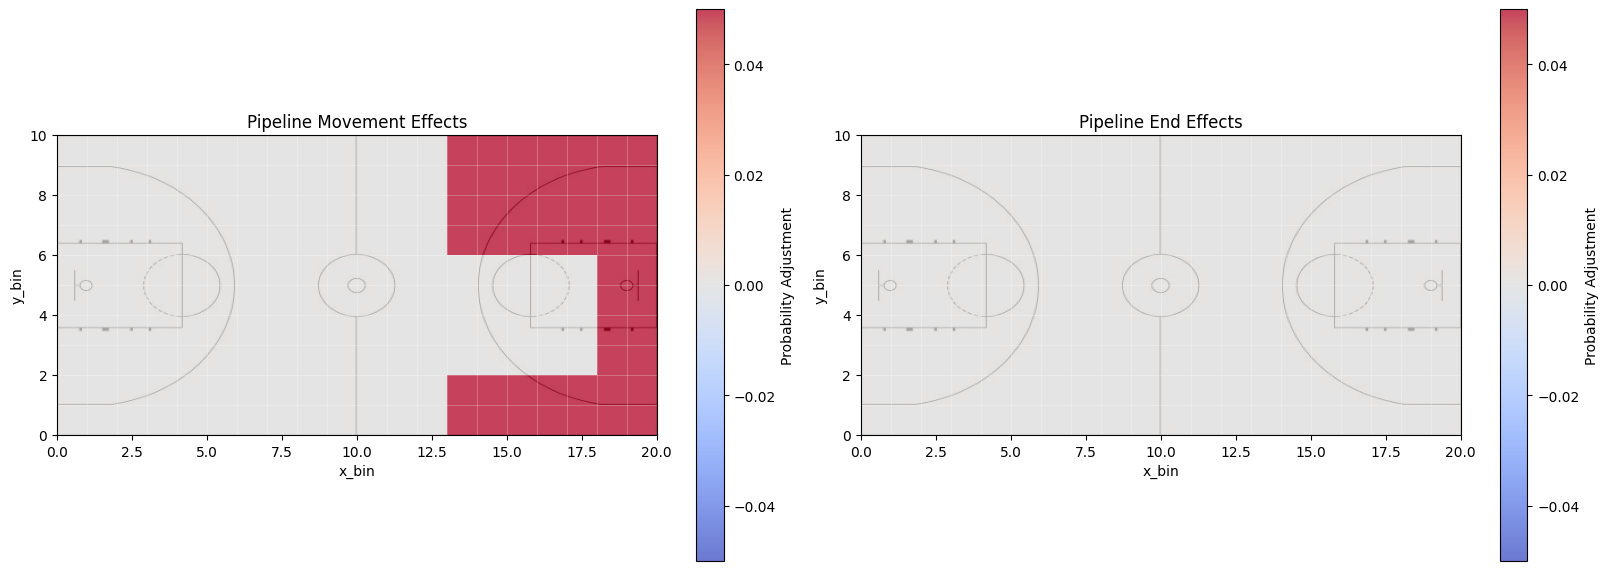


=== Processing single ===


Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 82.3397
λ_max (data): 1717.7625


Processing Bootstrap Datasets: 100%|██████████| 100/100 [05:41<00:00,  3.41s/it]

λ_qut (95th percentile null): 82.3397
λ_max (observed): 1717.7625
95% CI for λ_max (bootstrap): [1597.7736, 1729.7692]
Empirical p-value (λ_max > λ_qut): 0.0000


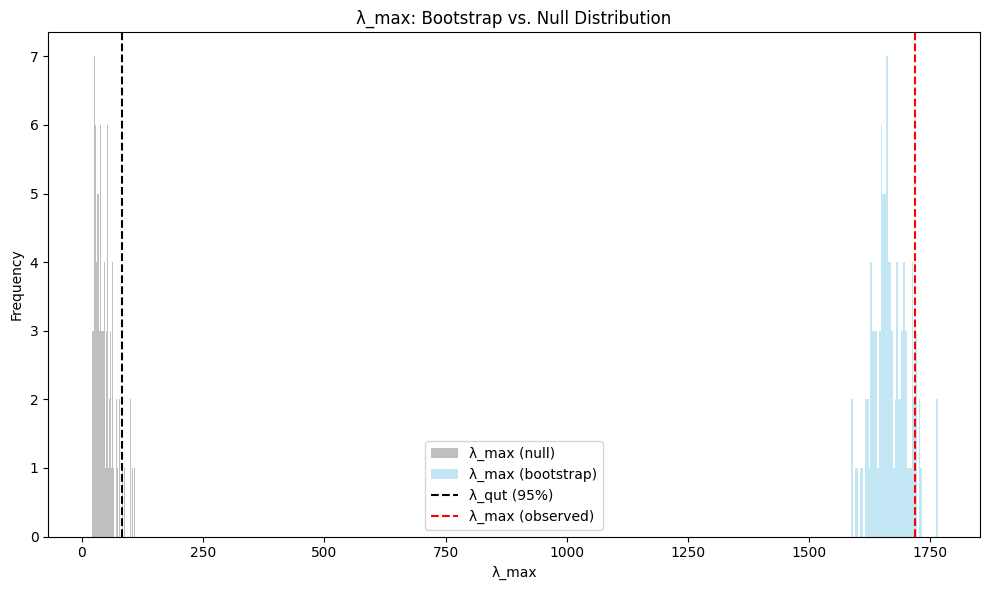

Plotting pointwise percentile maps at lambda = 82.3397


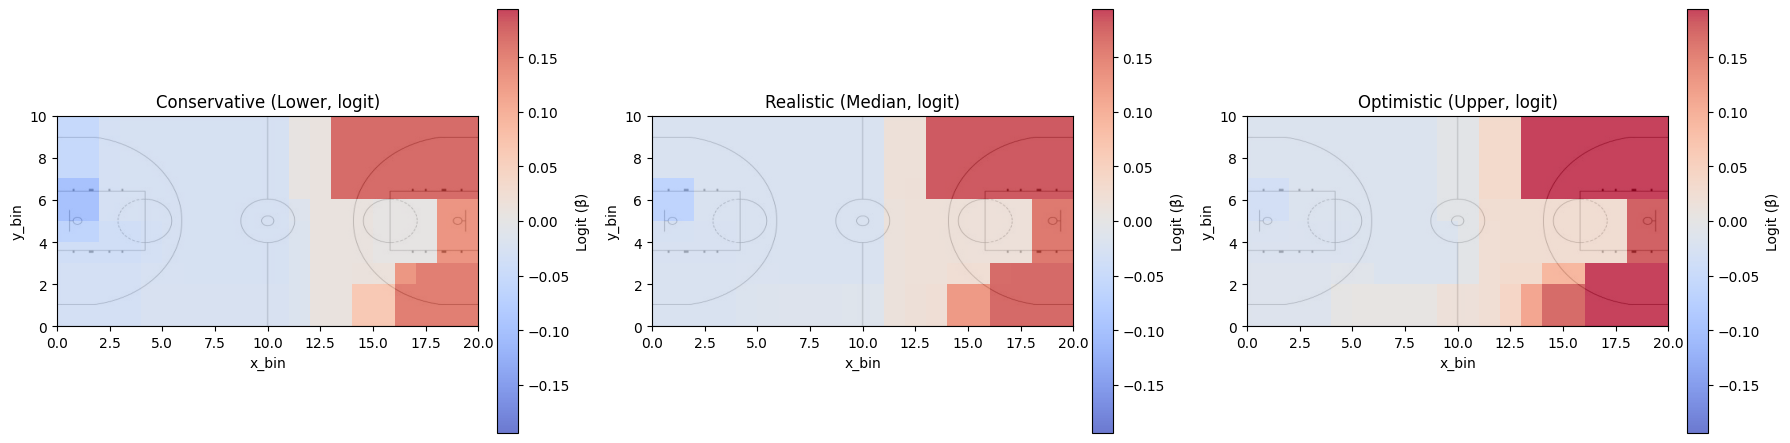

In [ ]:
# Profile 1 (seed 42): reference court pattern.

pipeline_profile_name = "reference"
pipeline_profile = simulation_profiles[pipeline_profile_name]
pipeline_seed = pipeline_profile["seed"]
# Copy the centralized profile so downstream exploratory edits stay local.
pipeline_movement_effects = np.array(pipeline_profile["movement_effects"], copy=True)
pipeline_end_effects = np.array(pipeline_profile["end_effects"], copy=True)

plot_effect_surfaces(pipeline_movement_effects, pipeline_end_effects, title_prefix="Pipeline")

# Sample real trajectories and convert the known spatial profile into one
# scoring probability per sampled possession.
pipeline_results = build_baseline_scoring_pipeline(
    pipeline_input_df,
    train_games=train_set,
    n_possessions=500,
    movement_effects=pipeline_movement_effects,
    end_effects=pipeline_end_effects,
    baseline_probability=0.30,
    random_state=pipeline_seed,
)

pipeline_sampled_movement = pipeline_results["sampled_movement"]
pipeline_sampled_binned_movement = pipeline_results["sampled_binned_movement"]
pipeline_qut_movement = pipeline_results["qut_movement"]
pipeline_visited_posssessions = pipeline_results["visited_posssessions"]
pipeline_baseline_scoring_probabilities = pipeline_results["baseline_scoring_probabilities"]

# Short aliases preserve compatibility with downstream exploratory cells.
visited_posssessions = pipeline_visited_posssessions
baseline_scoring_probabilities = pipeline_baseline_scoring_probabilities
# Draw a reproducible binary outcome from each possession probability.
pipeline_rng = np.random.default_rng(pipeline_seed)
baseline_scoring_probabilities["simulated_out"] = pipeline_rng.binomial(n=1, p=baseline_scoring_probabilities["scoring_probability"])

pipeline_simulated_scoring = baseline_scoring_probabilities[possession_cols + ["simulated_out"]]
pipeline_qut_movement = pipeline_qut_movement.merge(
    pipeline_simulated_scoring,
    on=possession_cols,
    how="left",
)
# Present the simulated label to QUT and discard columns its grid builder does not use.
pipeline_qut_movement["scored"] = pipeline_qut_movement["simulated_out"]
pipeline_qut_movement = pipeline_qut_movement[
    ["possession_number", "x_bin", "y_bin", "scored"]
].copy()

pipeline_n_bootstraps = 100
pipeline_mc_null = 100
pipeline_alpha = 0.05

# Release the previous profile before evaluating the next expensive call.
if "pipeline_qut_results" in globals():
    del pipeline_qut_results
gc.collect()
plt.close("all")

# Recover a TV-regularized spatial profile and quantify lambda uncertainty.
pipeline_qut_results = analyze_tv_logistic_single_game(
    pipeline_qut_movement,
    game_id=None,
    n_bootstraps=pipeline_n_bootstraps,
    n_possessions=10000,
    samples_per_possession=250,
    min_samples_required=100,
    mc_null=pipeline_mc_null,
    alpha=pipeline_alpha,
    court_image_path="court.jpg",
    show_progress=True,
    plot_pointwise_maps=True,
    plot_lambda_distributions=True,
    seed=pipeline_seed,
)

# display(pipeline_qut_movement)

# display(baseline_scoring_probabilities)


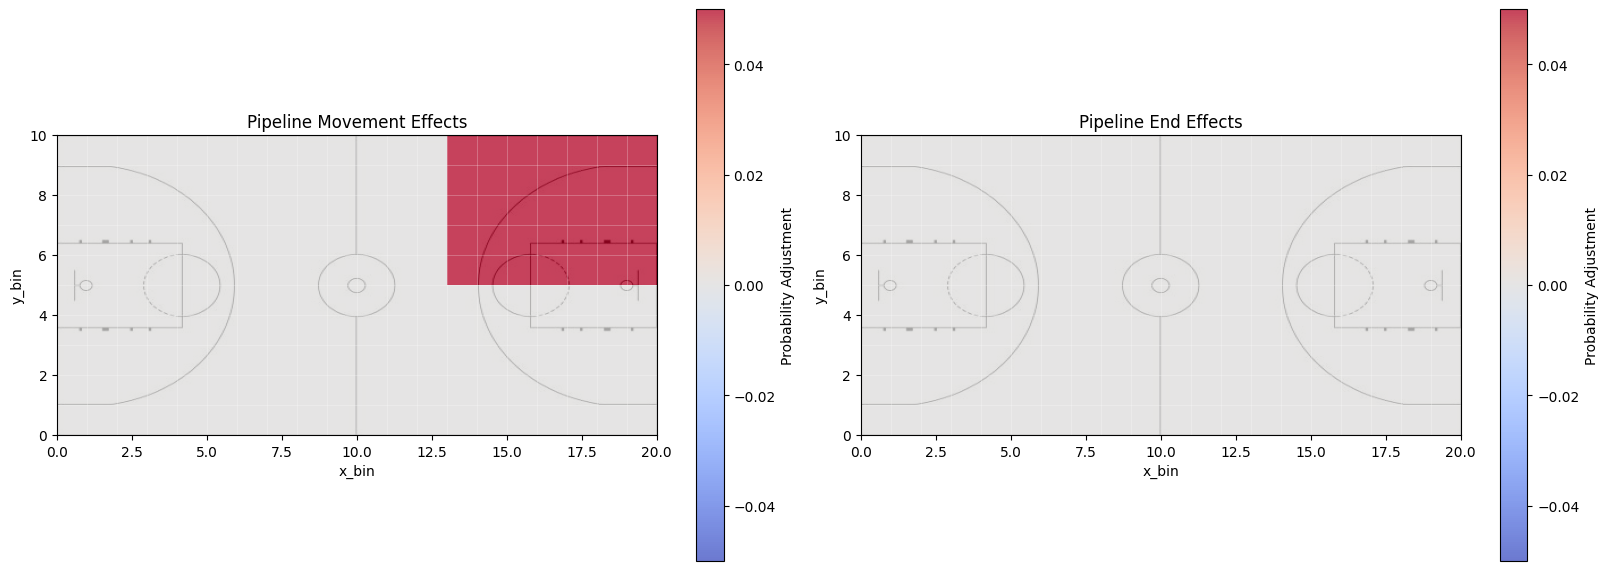


=== Processing single ===


Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 80.9076
λ_max (data): 1154.0798


Processing Bootstrap Datasets: 100%|██████████| 100/100 [05:31<00:00,  3.32s/it]

λ_qut (95th percentile null): 80.9076
λ_max (observed): 1154.0798
95% CI for λ_max (bootstrap): [1108.0047, 1261.9983]
Empirical p-value (λ_max > λ_qut): 0.0000


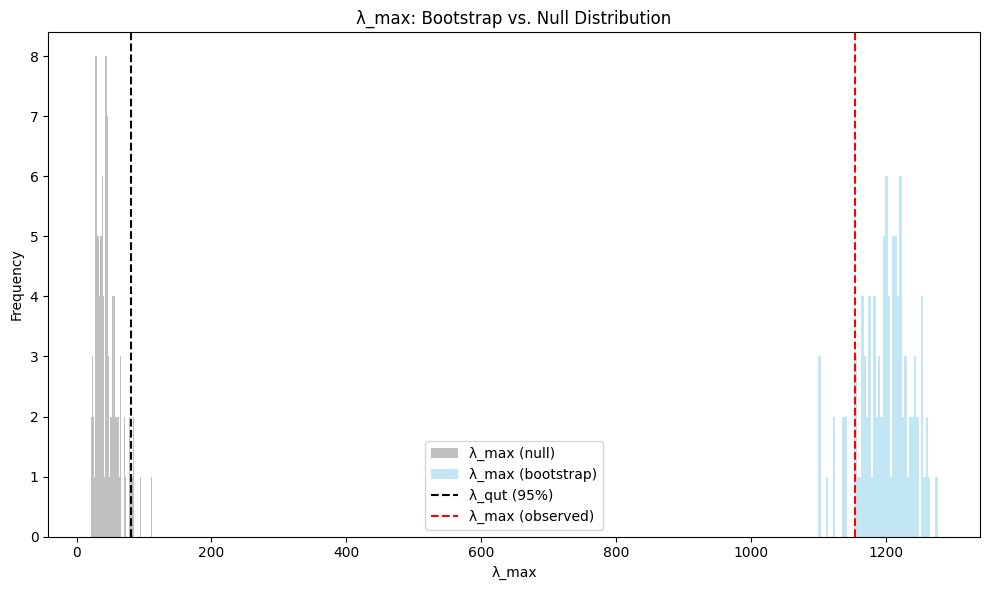

Plotting pointwise percentile maps at lambda = 80.9076


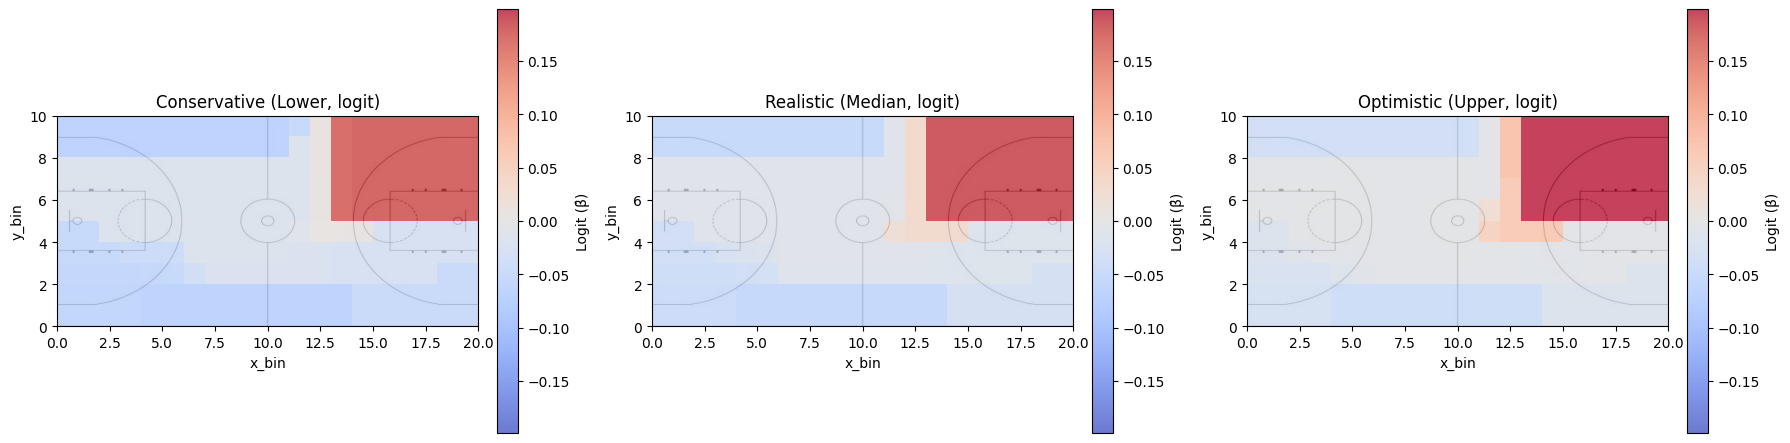

In [13]:
# Profile 2 (seed 43): emphasize the high-y side of the offensive half.
pipeline_profile_name = "high_y_side"
pipeline_profile = simulation_profiles[pipeline_profile_name]
pipeline_seed = pipeline_profile["seed"]
pipeline_movement_effects = np.array(pipeline_profile["movement_effects"], copy=True)
pipeline_end_effects = np.array(pipeline_profile["end_effects"], copy=True)

plot_effect_surfaces(pipeline_movement_effects, pipeline_end_effects, title_prefix="Pipeline")

# Plotting occurs unconditionally; the prompt gates the expensive QUT run.
ask = input("Do you want to run the pipeline with the current settings? (yes/no): ").strip().lower()

if ask == "yes":
    pipeline_results = build_baseline_scoring_pipeline(
        pipeline_input_df,
        train_games=train_set,
        n_possessions=500,
        movement_effects=pipeline_movement_effects,
        end_effects=pipeline_end_effects,
        baseline_probability=0.30,
        random_state=pipeline_seed,
    )

    pipeline_sampled_movement = pipeline_results["sampled_movement"]
    pipeline_sampled_binned_movement = pipeline_results["sampled_binned_movement"]
    pipeline_qut_movement = pipeline_results["qut_movement"]
    pipeline_visited_posssessions = pipeline_results["visited_posssessions"]
    pipeline_baseline_scoring_probabilities = pipeline_results["baseline_scoring_probabilities"]

    visited_posssessions = pipeline_visited_posssessions
    baseline_scoring_probabilities = pipeline_baseline_scoring_probabilities
    pipeline_rng = np.random.default_rng(pipeline_seed)
    baseline_scoring_probabilities["simulated_out"] = pipeline_rng.binomial(n=1, p=baseline_scoring_probabilities["scoring_probability"])

    pipeline_simulated_scoring = baseline_scoring_probabilities[possession_cols + ["simulated_out"]]
    pipeline_qut_movement = pipeline_qut_movement.merge(
        pipeline_simulated_scoring,
        on=possession_cols,
        how="left",
    )
    pipeline_qut_movement["scored"] = pipeline_qut_movement["simulated_out"]
    pipeline_qut_movement = pipeline_qut_movement[
        ["possession_number", "x_bin", "y_bin", "scored"]
    ].copy()

    pipeline_n_bootstraps = 100
    pipeline_mc_null = 100
    pipeline_alpha = 0.05

    # Release the previous profile before evaluating the next expensive call.
    if "pipeline_qut_results" in globals():
        del pipeline_qut_results
    gc.collect()
    plt.close("all")

    pipeline_qut_results = analyze_tv_logistic_single_game(
        pipeline_qut_movement,
        game_id=None,
        n_bootstraps=pipeline_n_bootstraps,
        n_possessions=10000,
        samples_per_possession=250,
        min_samples_required=100,
        mc_null=pipeline_mc_null,
        alpha=pipeline_alpha,
        court_image_path="court.jpg",
        show_progress=True,
        plot_pointwise_maps=True,
        plot_lambda_distributions=True,
        seed=pipeline_seed,
    )

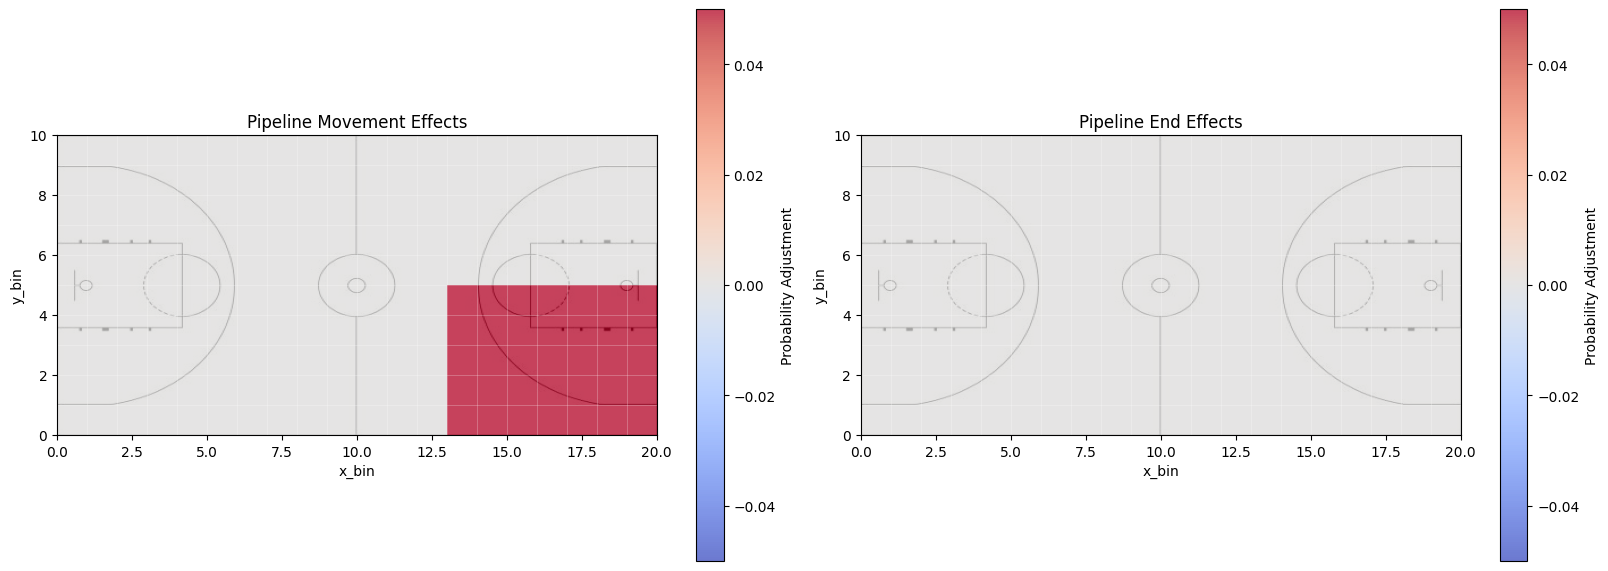


=== Processing single ===


Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 83.0711
λ_max (data): 1913.4657


Processing Bootstrap Datasets: 100%|██████████| 100/100 [05:39<00:00,  3.39s/it]

λ_qut (95th percentile null): 83.0711
λ_max (observed): 1913.4657
95% CI for λ_max (bootstrap): [1786.5839, 1916.6244]
Empirical p-value (λ_max > λ_qut): 0.0000


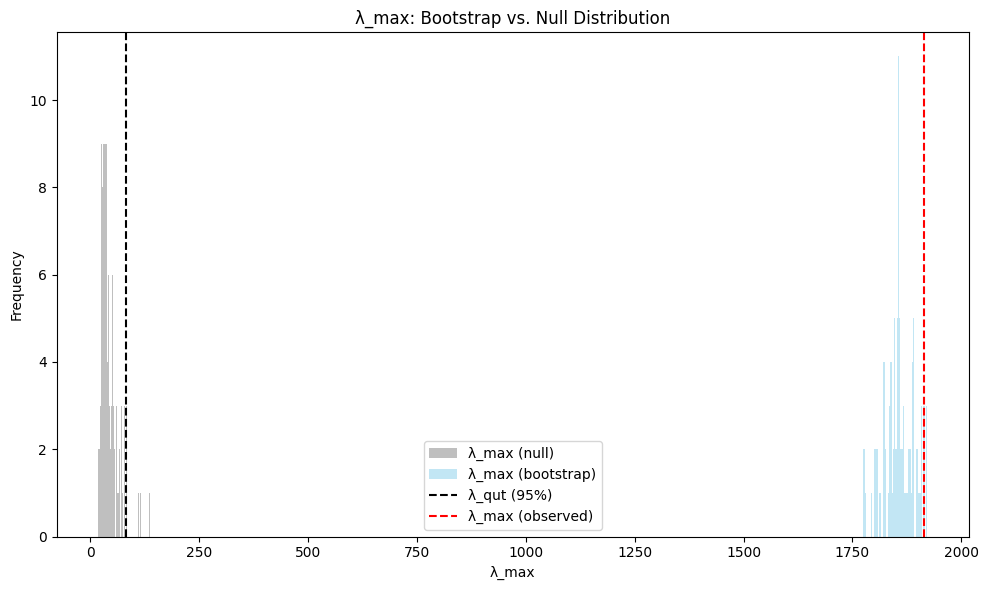

Plotting pointwise percentile maps at lambda = 83.0711


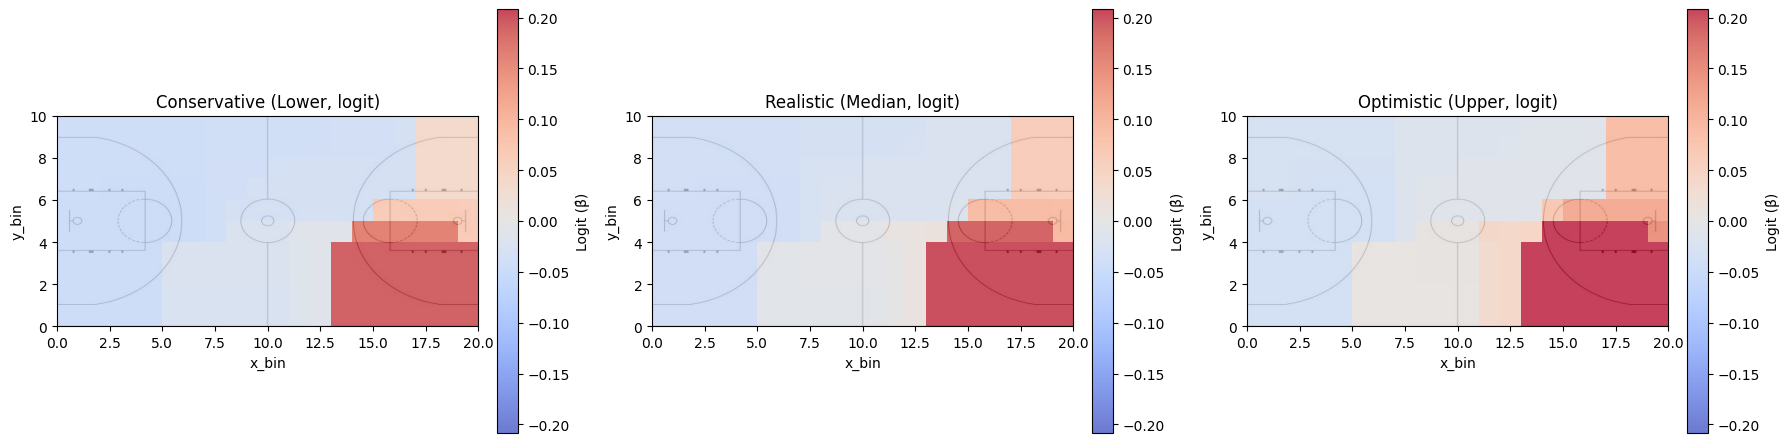

In [16]:
# Profile 3 (seed 44): emphasize the low-y side of the offensive half.
pipeline_profile_name = "low_y_side"
pipeline_profile = simulation_profiles[pipeline_profile_name]
pipeline_seed = pipeline_profile["seed"]
pipeline_movement_effects = np.array(pipeline_profile["movement_effects"], copy=True)
pipeline_end_effects = np.array(pipeline_profile["end_effects"], copy=True)

plot_effect_surfaces(pipeline_movement_effects, pipeline_end_effects, title_prefix="Pipeline")

# Plotting occurs unconditionally; the prompt gates the expensive QUT run.
ask = input("Do you want to run the pipeline with the current settings? (yes/no): ").strip().lower()

if ask == "yes":
    pipeline_results = build_baseline_scoring_pipeline(
        pipeline_input_df,
        train_games=train_set,
        n_possessions=500,
        movement_effects=pipeline_movement_effects,
        end_effects=pipeline_end_effects,
        baseline_probability=0.30,
        random_state=pipeline_seed,
    )

    pipeline_sampled_movement = pipeline_results["sampled_movement"]
    pipeline_sampled_binned_movement = pipeline_results["sampled_binned_movement"]
    pipeline_qut_movement = pipeline_results["qut_movement"]
    pipeline_visited_posssessions = pipeline_results["visited_posssessions"]
    pipeline_baseline_scoring_probabilities = pipeline_results["baseline_scoring_probabilities"]

    visited_posssessions = pipeline_visited_posssessions
    baseline_scoring_probabilities = pipeline_baseline_scoring_probabilities
    pipeline_rng = np.random.default_rng(pipeline_seed)
    baseline_scoring_probabilities["simulated_out"] = pipeline_rng.binomial(n=1, p=baseline_scoring_probabilities["scoring_probability"])

    pipeline_simulated_scoring = baseline_scoring_probabilities[possession_cols + ["simulated_out"]]
    pipeline_qut_movement = pipeline_qut_movement.merge(
        pipeline_simulated_scoring,
        on=possession_cols,
        how="left",
    )
    pipeline_qut_movement["scored"] = pipeline_qut_movement["simulated_out"]
    pipeline_qut_movement = pipeline_qut_movement[
        ["possession_number", "x_bin", "y_bin", "scored"]
    ].copy()

    pipeline_n_bootstraps = 100
    pipeline_mc_null = 100
    pipeline_alpha = 0.05

    # Release the previous profile before evaluating the next expensive call.
    if "pipeline_qut_results" in globals():
        del pipeline_qut_results
    gc.collect()
    plt.close("all")

    pipeline_qut_results = analyze_tv_logistic_single_game(
        pipeline_qut_movement,
        game_id=None,
        n_bootstraps=pipeline_n_bootstraps,
        n_possessions=10000,
        samples_per_possession=250,
        min_samples_required=100,
        mc_null=pipeline_mc_null,
        alpha=pipeline_alpha,
        court_image_path="court.jpg",
        show_progress=True,
        plot_pointwise_maps=True,
        plot_lambda_distributions=True,
        seed=pipeline_seed,
    )

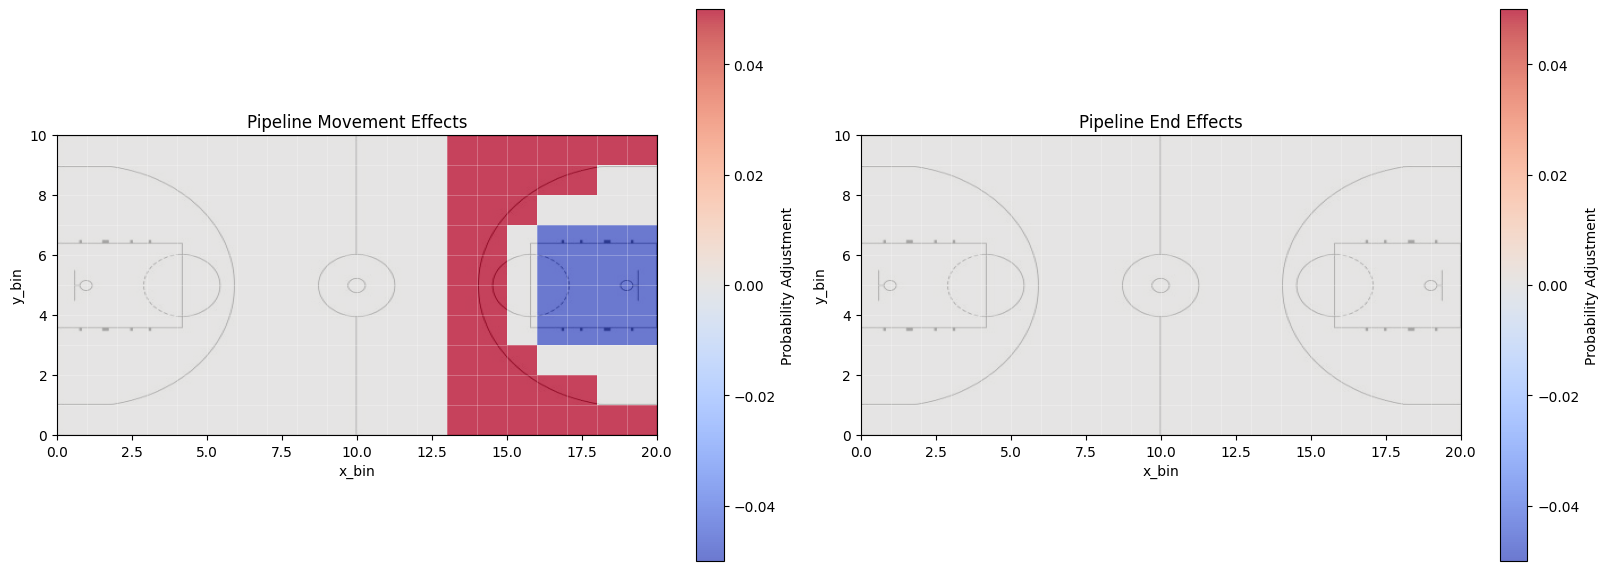


=== Processing single ===


Processing Bootstrap Datasets:   0%|          | 0/100 [00:00<?, ?it/s]

Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 79.1725
λ_max (data): 251.2832


Processing Bootstrap Datasets: 100%|██████████| 100/100 [05:32<00:00,  3.33s/it]

λ_qut (95th percentile null): 79.1725
λ_max (observed): 251.2832
95% CI for λ_max (bootstrap): [237.6856, 293.5863]
Empirical p-value (λ_max > λ_qut): 0.0000


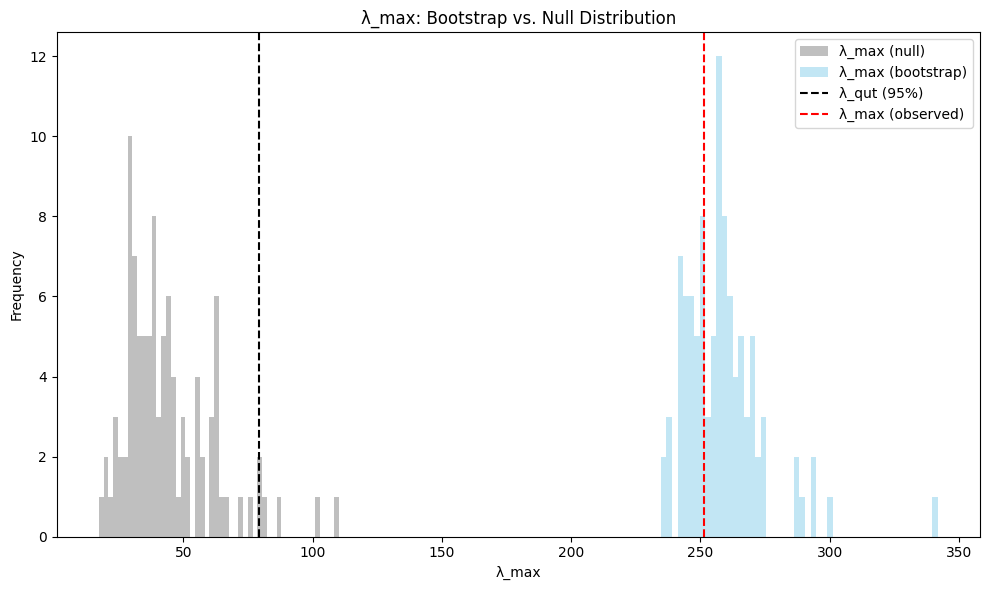

Plotting pointwise percentile maps at lambda = 79.1725


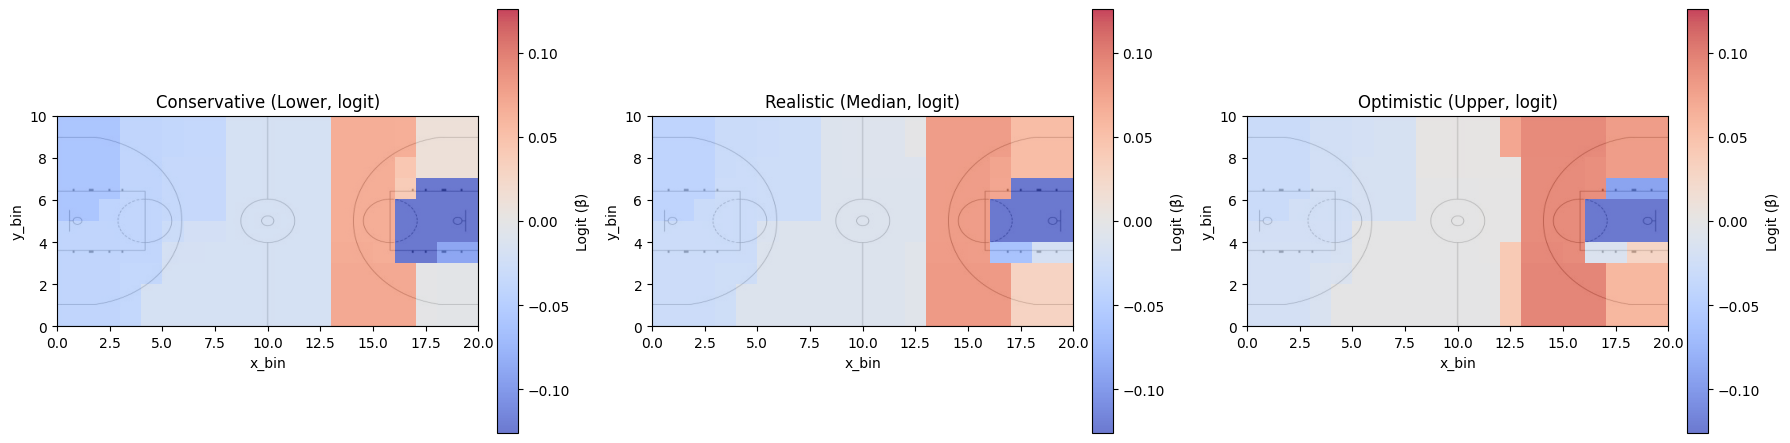

In [11]:
# Profile 4 (seed 45): stepped perimeter-like signal with an interior penalty.
pipeline_profile_name = "perimeter"
pipeline_profile = simulation_profiles[pipeline_profile_name]
pipeline_seed = pipeline_profile["seed"]
pipeline_movement_effects = np.array(pipeline_profile["movement_effects"], copy=True)
pipeline_end_effects = np.array(pipeline_profile["end_effects"], copy=True)

plot_effect_surfaces(pipeline_movement_effects, pipeline_end_effects, title_prefix="Pipeline")

# Plotting occurs unconditionally; the prompt gates the expensive QUT run.
ask = input("Do you want to run the pipeline with the current settings? (yes/no): ").strip().lower()

if ask == "yes":
    pipeline_results = build_baseline_scoring_pipeline(
        pipeline_input_df,
        train_games=train_set,
        n_possessions=500,
        movement_effects=pipeline_movement_effects,
        end_effects=pipeline_end_effects,
        baseline_probability=0.30,
        random_state=pipeline_seed,
    )

    pipeline_sampled_movement = pipeline_results["sampled_movement"]
    pipeline_sampled_binned_movement = pipeline_results["sampled_binned_movement"]
    pipeline_qut_movement = pipeline_results["qut_movement"]
    pipeline_visited_posssessions = pipeline_results["visited_posssessions"]
    pipeline_baseline_scoring_probabilities = pipeline_results["baseline_scoring_probabilities"]

    visited_posssessions = pipeline_visited_posssessions
    baseline_scoring_probabilities = pipeline_baseline_scoring_probabilities
    pipeline_rng = np.random.default_rng(pipeline_seed)
    baseline_scoring_probabilities["simulated_out"] = pipeline_rng.binomial(n=1, p=baseline_scoring_probabilities["scoring_probability"])

    pipeline_simulated_scoring = baseline_scoring_probabilities[possession_cols + ["simulated_out"]]
    pipeline_qut_movement = pipeline_qut_movement.merge(
        pipeline_simulated_scoring,
        on=possession_cols,
        how="left",
    )
    pipeline_qut_movement["scored"] = pipeline_qut_movement["simulated_out"]
    pipeline_qut_movement = pipeline_qut_movement[
        ["possession_number", "x_bin", "y_bin", "scored"]
    ].copy()

    pipeline_n_bootstraps = 100
    pipeline_mc_null = 100
    pipeline_alpha = 0.05

    # Release the previous profile before evaluating the next expensive call.
    if "pipeline_qut_results" in globals():
        del pipeline_qut_results
    gc.collect()
    plt.close("all")

    pipeline_qut_results = analyze_tv_logistic_single_game(
        pipeline_qut_movement,
        game_id=None,
        n_bootstraps=pipeline_n_bootstraps,
        n_possessions=10000,
        samples_per_possession=250,
        min_samples_required=100,
        mc_null=pipeline_mc_null,
        alpha=pipeline_alpha,
        court_image_path="court.jpg",
        show_progress=True,
        plot_pointwise_maps=True,
        plot_lambda_distributions=True,
        seed=pipeline_seed,
    )

## 4. Reading the outputs

After a profile run, the main objects are:

- `simulation_profiles`: stable named copies of all planted movement/end surfaces and their original seeds. The corresponding arrays are also available as `reference_*`, `high_y_side_*`, `low_y_side_*`, and `perimeter_*`.
- `pipeline_movement_effects` and `pipeline_end_effects`: the known input signal.
- `pipeline_visited_posssessions`: one row per sampled possession-sector pair.
- `pipeline_baseline_scoring_probabilities`: the component breakdown and final probability for each sampled possession.
- `pipeline_qut_movement`: the four-column QUT input containing the possession identifier, two spatial-bin coordinates, and synthetic `scored` outcome.
- `pipeline_qut_results`: lambda statistics, null/bootstrap distributions, bootstrap coefficient samples, and pointwise percentile maps. Bootstrap tracking tables and mean/standard-deviation maps are not retained.

Useful reconstruction checks include spatial overlap between the nonzero input and recovered regions, sign agreement, effect ranking across regions, and whether pointwise intervals exclude zero where a signal was planted. Because outcomes are random and TV regularization smooths adjacent bins, exact cell-for-cell recovery is not expected.

## Project notes

- Use game `0021500390` for the projection example — done.
- Show the slack-variable mathematics — in progress.
- Four simulations: expected/reference pattern, one-side emphasis, perimeter shooting, and opposite-side emphasis with minimal under-basket emphasis — done.
- Investigate player-measurement covariates.
- Develop quantitative comparisons between the planted simulation profile and the bootstrapped reconstruction.

## 5. Incremental full-game and quarter experiments

This section compares reconstruction stability as three bootstrap controls are changed one at a time:

- `samples_per_possession`: tracking rows drawn for each sampled possession (`50`, `100`, `150`, `200`).
- `possessions_per_bootstrap`: possession draws in one bootstrap dataset (`100`, `1,000`, `10,000`). This is passed to `analyze_tv_logistic_single_game` as `n_possessions`.
- `n_bootstraps`: independently constructed bootstrap datasets (`10`, `50`, `100`, `500`).

The baseline configuration is 200 samples per possession, 1,000 possessions per bootstrap, and 100 bootstraps. Each sweep changes only its named parameter, so differences are interpretable without running a full Cartesian product. Repeated baseline configurations are cached by the runner.

Each selected named profile now uses two pooled recovery datasets: five 100-possession full-game units (500 distinct source possessions) and eighteen 28-possession quarter units (504 distinct source possessions). Every unit retains `simulation_unit_id` and `possession_in_unit`, so the intended game/quarter sizes are preserved even though the recovery analysis pools their information. `QUARTER_POSSESSION_TARGET` can be set anywhere from 25 through 30.

Movement trajectories are sampled once per scenario, oriented with `bin_and_flip(..., flip="no")`, and reused across all selected profiles. In the current helper, the apparently inverted `"no"` value is what activates the home/away, half, and game-level rotations. The same scenario-level uniform random numbers are also used to convert each profile's probabilities into outcomes. Consequently, differences between profile reconstructions are driven by the planted effects rather than different trajectory samples or unrelated outcome randomness. The available names are `reference`, `high_y_side`, `low_y_side`, and `perimeter`; edit `EXPERIMENT_PROFILE_NAMES` to run any subset. This section reads the Section 0 registry directly, so the four expensive profile experiment cells in Section 3 do not need to be run first.

When `PLOT_INCREMENTAL_HEATMAPS` is enabled, every unique supported configuration displays the same three pointwise percentile maps used above: conservative/lower, median, and optimistic/upper logit surfaces. The result is also retained under `incremental_experiment_results[run_id]["pointwise"]`. Heatmap generation adds one TV-logistic fit for every bootstrap replicate, so it materially increases runtime. A run banner printed before each analysis documents the selected profile, scenario, changing parameter, bootstrap dimensions, estimated resampled rows, cache behavior, and any skipped or failed configuration.

In [21]:
FULL_GAME_POSSESSIONS_PER_UNIT = 92
FULL_GAME_SIMULATION_UNITS = 5
QUARTER_POSSESSION_RANGE = (20, 25)
QUARTER_POSSESSION_TARGET = 23
QUARTER_SIMULATION_UNITS = 18
EXPERIMENT_SEED = 142
EXPERIMENT_PROFILE_NAMES = ("reference", "high_y_side", "low_y_side", "perimeter")

if not QUARTER_POSSESSION_RANGE[0] <= QUARTER_POSSESSION_TARGET <= QUARTER_POSSESSION_RANGE[1]:
    raise ValueError("QUARTER_POSSESSION_TARGET must be between 25 and 30.")
if FULL_GAME_SIMULATION_UNITS < 1 or QUARTER_SIMULATION_UNITS < 1:
    raise ValueError("Simulation-unit counts must be at least 1.")

missing_profiles = set(EXPERIMENT_PROFILE_NAMES).difference(simulation_profiles)
if missing_profiles:
    raise ValueError(f"Run the missing Section 0 profile definitions first: {sorted(missing_profiles)}")


def build_shared_scenario_trajectories(
    df,
    train_games,
    possessions_per_unit,
    n_units,
    seed=42,
    flip="yes",
):
    """Sample and bin trajectories once for reuse by every planted profile."""
    if possessions_per_unit < 1 or n_units < 1:
        raise ValueError("possessions_per_unit and n_units must be at least 1.")

    total_possessions = int(possessions_per_unit * n_units)
    sampled = sample_possessions_from_games(
        df,
        game_ids=train_games,
        n_possessions=total_possessions,
        random_state=seed,
        reindex_possessions=True,
    )
    sampled["simulation_unit_id"] = sampled["possession_number"] // possessions_per_unit
    sampled["possession_in_unit"] = sampled["possession_number"] % possessions_per_unit

    unit_cols = ["simulation_unit_id", "possession_in_unit"]
    unit_assignments = sampled[possession_cols + unit_cols].drop_duplicates().copy()
    unit_counts = unit_assignments.groupby("simulation_unit_id")["possession_number"].nunique()
    if len(unit_counts) != n_units or not unit_counts.eq(possessions_per_unit).all():
        raise RuntimeError("The sampled trajectories do not form complete simulation units.")

    binned = bin_and_flip(sampled, flip=flip)
    binned["sector"] = list(zip(binned["x_bin"], binned["y_bin"]))
    visited = build_visited_possessions(binned)
    visited = visited.merge(
        unit_assignments,
        on=possession_cols,
        how="left",
        validate="many_to_one",
    )

    return {
        "sampled_movement": sampled,
        "sampled_binned_movement": binned,
        "qut_movement": binned,
        "visited_possessions": visited,
        "unit_assignments": unit_assignments,
        "possessions_per_unit": int(possessions_per_unit),
        "n_units": int(n_units),
        "n_simulated_possessions": total_possessions,
        "trajectory_seed": int(seed),
    }


def apply_profile_to_shared_scenario(
    shared_trajectories,
    movement_effects,
    end_effects,
    baseline_probability=0.30,
    outcome_seed=42,
):
    """Apply one profile and common random outcome draws to shared trajectories."""
    probabilities = create_baseline_scoring_probabilities(
        shared_trajectories["visited_possessions"],
        movement_effects=movement_effects,
        end_effects=end_effects,
        baseline_probability=baseline_probability,
    )
    probabilities = probabilities.merge(
        shared_trajectories["unit_assignments"],
        on=possession_cols,
        how="left",
        validate="one_to_one",
    )

    rng = np.random.default_rng(outcome_seed)
    probabilities["outcome_uniform"] = rng.random(len(probabilities))
    probabilities["simulated_out"] = (
        probabilities["outcome_uniform"] < probabilities["scoring_probability"]
    ).astype(np.int8)

    simulated_scoring = probabilities[possession_cols + ["simulated_out"]]
    qut_input = shared_trajectories["qut_movement"].merge(
        simulated_scoring,
        on=possession_cols,
        how="left",
        validate="many_to_one",
    )
    qut_input["scored"] = qut_input["simulated_out"]
    qut_input = qut_input[[
        "simulation_unit_id",
        "possession_in_unit",
        "possession_number",
        "x_bin",
        "y_bin",
        "scored",
    ]].copy()

    actual_possessions = qut_input["possession_number"].nunique()
    expected_possessions = shared_trajectories["n_simulated_possessions"]
    if actual_possessions != expected_possessions:
        raise RuntimeError(
            f"Expected {expected_possessions} possessions but constructed {actual_possessions}."
        )

    return {
        "shared_trajectories": shared_trajectories,
        "baseline_scoring_probabilities": probabilities,
        "qut_input": qut_input,
        "n_simulated_possessions": actual_possessions,
        "possessions_per_unit": shared_trajectories["possessions_per_unit"],
        "n_units": shared_trajectories["n_units"],
        "trajectory_seed": shared_trajectories["trajectory_seed"],
        "outcome_seed": int(outcome_seed),
    }


scenario_unit_config = {
    "full_game": {
        "possessions_per_unit": FULL_GAME_POSSESSIONS_PER_UNIT,
        "n_units": FULL_GAME_SIMULATION_UNITS,
    },
    "quarter": {
        "possessions_per_unit": QUARTER_POSSESSION_TARGET,
        "n_units": QUARTER_SIMULATION_UNITS,
    },
}

shared_scenario_trajectories = {}
for scenario_index, (scenario_name, config) in enumerate(scenario_unit_config.items()):
    shared_scenario_trajectories[scenario_name] = build_shared_scenario_trajectories(
        pipeline_input_df,
        train_games=train_set,
        possessions_per_unit=config["possessions_per_unit"],
        n_units=config["n_units"],
        seed=EXPERIMENT_SEED + scenario_index,
        flip="no",  # In bin_and_flip, "no" activates the orientation rotations.
    )

scenario_rows = []
simulation_scenarios = {profile_name: {} for profile_name in EXPERIMENT_PROFILE_NAMES}
for profile_name in EXPERIMENT_PROFILE_NAMES:
    profile = simulation_profiles[profile_name]
    for scenario_index, (scenario_name, shared) in enumerate(shared_scenario_trajectories.items()):
        common_outcome_seed = EXPERIMENT_SEED + 100 + scenario_index
        simulation = apply_profile_to_shared_scenario(
            shared,
            movement_effects=profile["movement_effects"],
            end_effects=profile["end_effects"],
            baseline_probability=0.30,
            outcome_seed=common_outcome_seed,
        )
        simulation["profile"] = profile_name
        simulation["scenario"] = scenario_name
        simulation_scenarios[profile_name][scenario_name] = simulation
        scenario_rows.append({
            "profile": profile_name,
            "scenario": scenario_name,
            "simulation_units": shared["n_units"],
            "possessions_per_unit": shared["possessions_per_unit"],
            "simulated_possessions": shared["n_simulated_possessions"],
            "trajectory_seed": shared["trajectory_seed"],
            "outcome_seed": common_outcome_seed,
        })

scenario_specs = pd.DataFrame(scenario_rows)
scenario_specs

,profile,scenario,simulation_units,possessions_per_unit,simulated_possessions,trajectory_seed,outcome_seed
0,reference,full_game,5,92,460,142,242
1,reference,quarter,18,23,414,143,243
2,high_y_side,full_game,5,92,460,142,242
3,high_y_side,quarter,18,23,414,143,243
4,low_y_side,full_game,5,92,460,142,242
5,low_y_side,quarter,18,23,414,143,243
6,perimeter,full_game,5,92,460,142,242
7,perimeter,quarter,18,23,414,143,243


In [24]:
SAMPLES_PER_POSSESSION_VALUES = (50, 100, 150, 200, 250)
POSSESSIONS_PER_BOOTSTRAP_VALUES = (100, 1000, 10000)
BOOTSTRAP_COUNT_VALUES = (10, 50, 100, 500)

BASE_SAMPLES_PER_POSSESSION = 200
BASE_POSSESSIONS_PER_BOOTSTRAP = 1000
BASE_BOOTSTRAP_COUNT = 100


def _positive_integer_values(values, name):
    checked = tuple(int(value) for value in values)
    if not checked or any(value < 1 for value in checked):
        raise ValueError(f"{name} must contain positive integers.")
    return checked


def build_incremental_experiment_plan(
    scenarios,
    samples_per_possession_values=SAMPLES_PER_POSSESSION_VALUES,
    possessions_per_bootstrap_values=POSSESSIONS_PER_BOOTSTRAP_VALUES,
    bootstrap_count_values=BOOTSTRAP_COUNT_VALUES,
    base_samples_per_possession=BASE_SAMPLES_PER_POSSESSION,
    base_possessions_per_bootstrap=BASE_POSSESSIONS_PER_BOOTSTRAP,
    base_n_bootstraps=BASE_BOOTSTRAP_COUNT,
):
    """Create one-factor-at-a-time parameter rows for every scenario."""
    sweep_values = {
        "samples_per_possession": _positive_integer_values(
            samples_per_possession_values, "samples_per_possession_values"
        ),
        "possessions_per_bootstrap": _positive_integer_values(
            possessions_per_bootstrap_values, "possessions_per_bootstrap_values"
        ),
        "n_bootstraps": _positive_integer_values(
            bootstrap_count_values, "bootstrap_count_values"
        ),
    }
    baseline = {
        "samples_per_possession": int(base_samples_per_possession),
        "possessions_per_bootstrap": int(base_possessions_per_bootstrap),
        "n_bootstraps": int(base_n_bootstraps),
    }
    _positive_integer_values(baseline.values(), "baseline values")

    rows = []
    for scenario in scenarios.itertuples(index=False):
        for parameter, values in sweep_values.items():
            for value in values:
                settings = baseline.copy()
                settings[parameter] = value
                rows.append({
                    "run_id": f"{scenario.profile}__{scenario.scenario}__{parameter}__{value}",
                    "profile": scenario.profile,
                    "scenario": scenario.scenario,
                    "simulation_units": int(scenario.simulation_units),
                    "possessions_per_unit": int(scenario.possessions_per_unit),
                    "simulated_possessions": int(scenario.simulated_possessions),
                    "parameter": parameter,
                    "value": value,
                    **settings,
                })

    return pd.DataFrame(rows)


incremental_experiment_plan = build_incremental_experiment_plan(scenario_specs)
incremental_experiment_plan

,run_id,profile,scenario,simulation_units,possessions_per_unit,simulated_possessions,parameter,value,samples_per_possession,possessions_per_bootstrap,n_bootstraps
0,reference__full_game__samples_per_possession__50,reference,full_game,5,92,460,samples_per_possession,50,50,1000,100
1,reference__full_game__samples_per_possession__100,reference,full_game,5,92,460,samples_per_possession,100,100,1000,100
2,reference__full_game__samples_per_possession__150,reference,full_game,5,92,460,samples_per_possession,150,150,1000,100
3,reference__full_game__samples_per_possession__200,reference,full_game,5,92,460,samples_per_possession,200,200,1000,100
4,reference__full_game__samples_per_possession__250,reference,full_game,5,92,460,samples_per_possession,250,250,1000,100
...,...,...,...,...,...,...,...,...,...,...,...
91,perimeter__quarter__possessions_per_bootstrap_...,perimeter,quarter,18,23,414,possessions_per_bootstrap,10000,200,10000,100
92,perimeter__quarter__n_bootstraps__10,perimeter,quarter,18,23,414,n_bootstraps,10,200,1000,10
93,perimeter__quarter__n_bootstraps__50,perimeter,quarter,18,23,414,n_bootstraps,50,200,1000,50
94,perimeter__quarter__n_bootstraps__100,perimeter,quarter,18,23,414,n_bootstraps,100,200,1000,100



INCREMENTAL TV-LOGISTIC/QUT EXPERIMENT
--------------------------------------------------------------------------------
Plan rows selected: 12
Unique supported analyses: 10
Profiles: reference
Scenarios: full_game
Trajectory control: each scenario uses one shared trajectory sample across profiles.
Source-possession eligibility threshold: 50 tracking rows
Monte Carlo null simulations per unique analysis: 100
Heatmaps: enabled (lower, median, and upper pointwise logit maps).
Heatmaps require one additional TV-logistic fit per bootstrap replicate.

PLAN ROW 1/12 | reference__full_game__samples_per_possession__50
Profile/scenario: reference / full_game
Source construction: 5 units x 92 possessions = 460 distinct source possessions
Sweep value: samples_per_possession = 50
Bootstrap design: 100 replicates x 1,000 possessions x 50 tracking rows
Rows per bootstrap: 50,000
Estimated resampled rows across replicates: 5,000,000
Action: run QUT/bootstrap analysis and generate requested outputs.



Processing Bootstrap Datasets:   0%|          | 0/100 [00:00<?, ?it/s]

Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 9.3943
λ_max (data): 43.1717


Processing Bootstrap Datasets: 100%|██████████| 100/100 [00:47<00:00,  2.10it/s]

λ_qut (95th percentile null): 9.3943
λ_max (observed): 43.1717
95% CI for λ_max (bootstrap): [24.8790, 42.0131]
Empirical p-value (λ_max > λ_qut): 0.0000


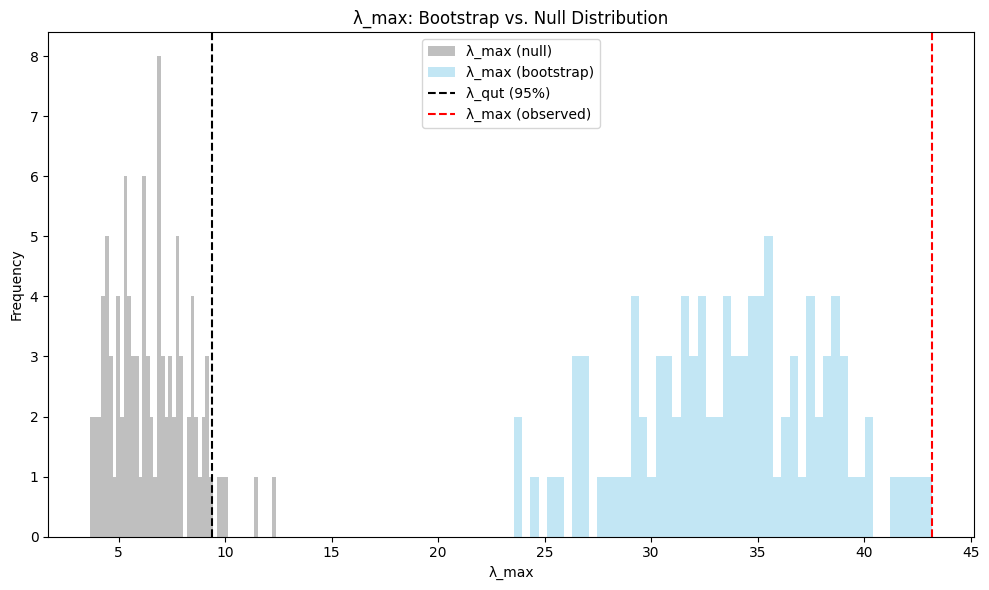

Plotting pointwise percentile maps at lambda = 9.3943


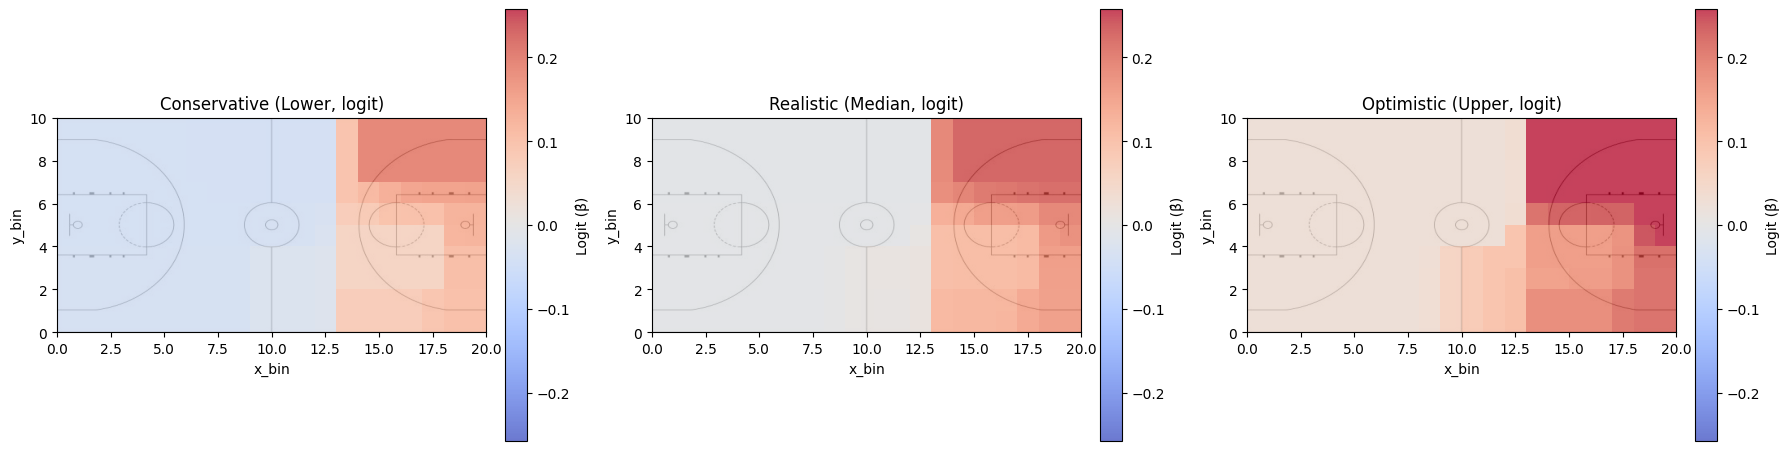

Completed in 47.90 seconds. Pointwise heatmaps were displayed and retained.

PLAN ROW 2/12 | reference__full_game__samples_per_possession__100
Profile/scenario: reference / full_game
Source construction: 5 units x 92 possessions = 460 distinct source possessions
Sweep value: samples_per_possession = 100
Bootstrap design: 100 replicates x 1,000 possessions x 100 tracking rows
Rows per bootstrap: 100,000
Estimated resampled rows across replicates: 10,000,000
Action: run QUT/bootstrap analysis and generate requested outputs.

=== Processing single ===


Processing Bootstrap Datasets:   0%|          | 0/100 [00:00<?, ?it/s]

Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 11.5505
λ_max (data): 48.6498


Processing Bootstrap Datasets: 100%|██████████| 100/100 [00:50<00:00,  1.96it/s]

λ_qut (95th percentile null): 11.5505
λ_max (observed): 48.6498
95% CI for λ_max (bootstrap): [31.7510, 48.5461]
Empirical p-value (λ_max > λ_qut): 0.0000


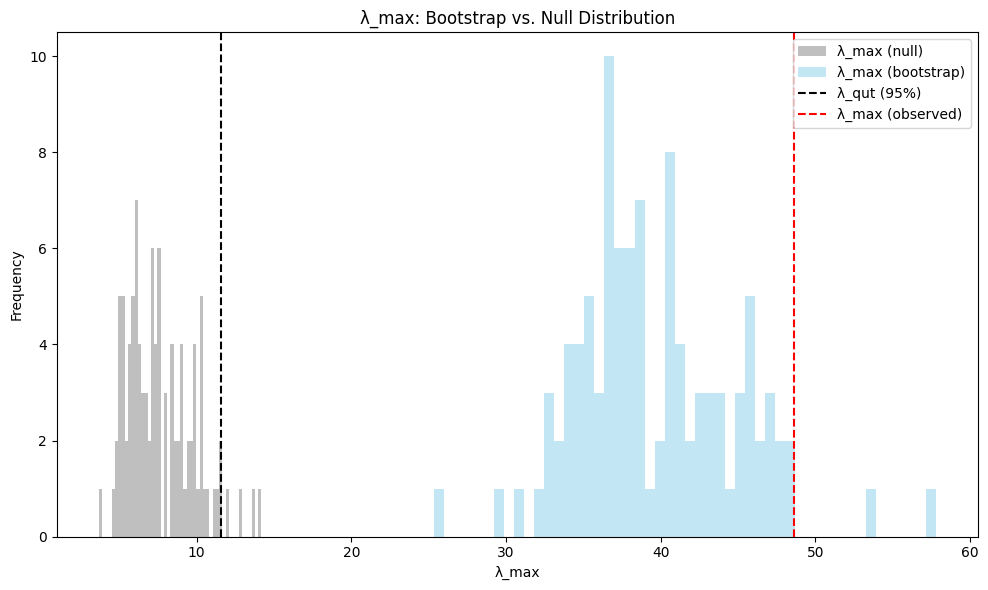

Plotting pointwise percentile maps at lambda = 11.5505


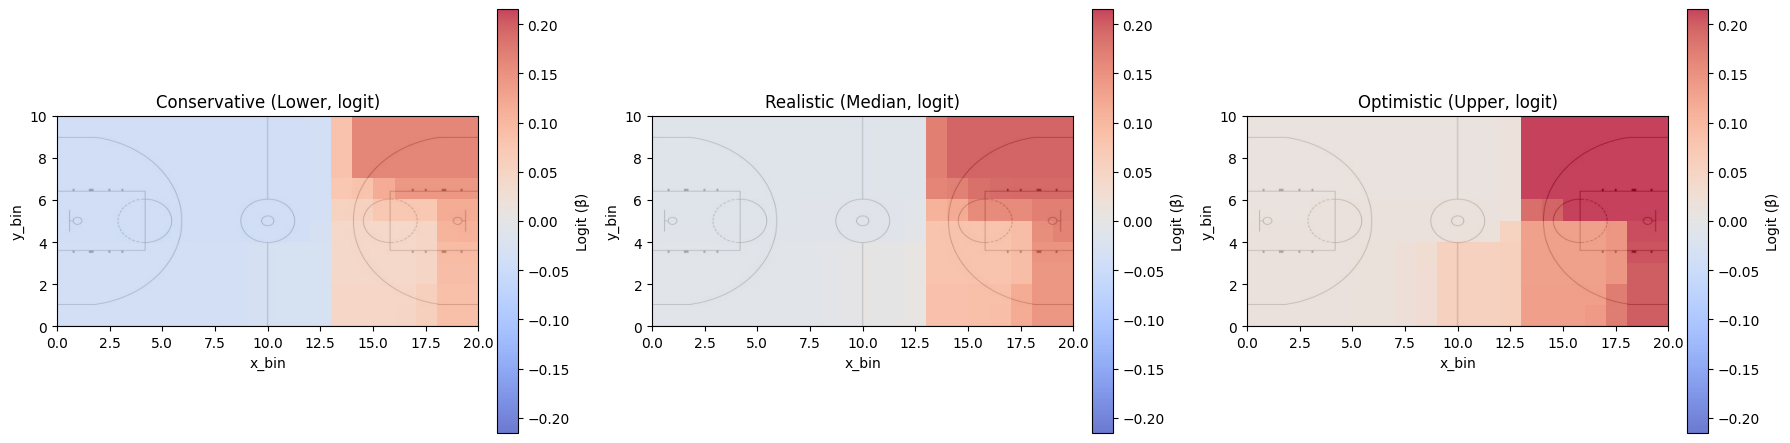

Completed in 51.26 seconds. Pointwise heatmaps were displayed and retained.

PLAN ROW 3/12 | reference__full_game__samples_per_possession__150
Profile/scenario: reference / full_game
Source construction: 5 units x 92 possessions = 460 distinct source possessions
Sweep value: samples_per_possession = 150
Bootstrap design: 100 replicates x 1,000 possessions x 150 tracking rows
Rows per bootstrap: 150,000
Estimated resampled rows across replicates: 15,000,000
Action: run QUT/bootstrap analysis and generate requested outputs.

=== Processing single ===


Processing Bootstrap Datasets:   0%|          | 0/100 [00:00<?, ?it/s]

Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 11.8817
λ_max (data): 51.9960


Processing Bootstrap Datasets: 100%|██████████| 100/100 [00:54<00:00,  1.83it/s]

λ_qut (95th percentile null): 11.8817
λ_max (observed): 51.9960
95% CI for λ_max (bootstrap): [34.9869, 52.1568]
Empirical p-value (λ_max > λ_qut): 0.0000


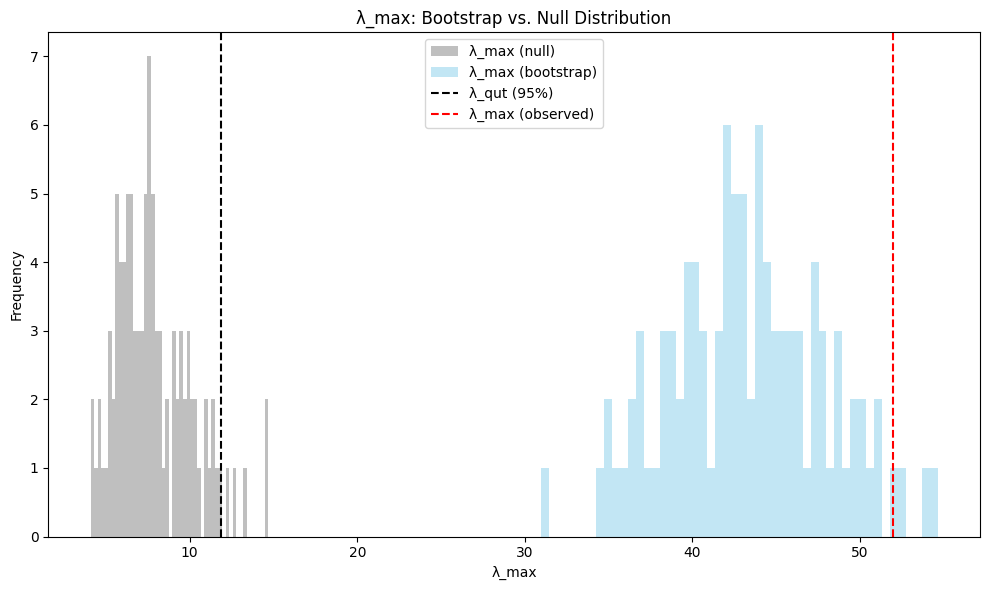

Plotting pointwise percentile maps at lambda = 11.8817


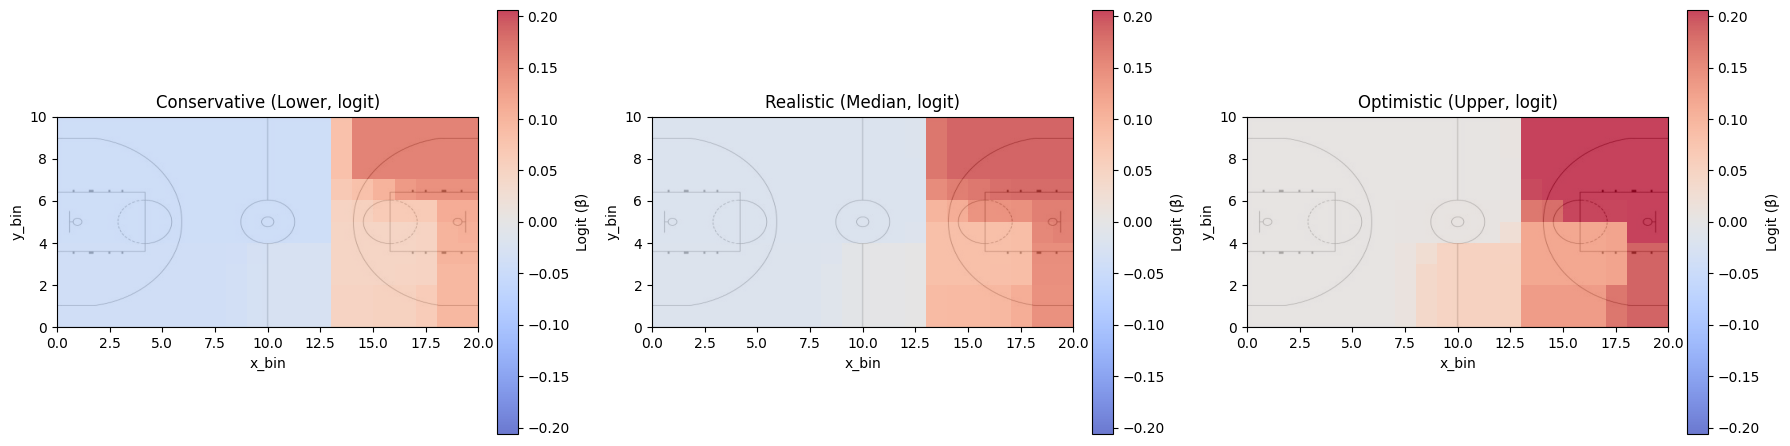

Completed in 54.96 seconds. Pointwise heatmaps were displayed and retained.

PLAN ROW 4/12 | reference__full_game__samples_per_possession__200
Profile/scenario: reference / full_game
Source construction: 5 units x 92 possessions = 460 distinct source possessions
Sweep value: samples_per_possession = 200
Bootstrap design: 100 replicates x 1,000 possessions x 200 tracking rows
Rows per bootstrap: 200,000
Estimated resampled rows across replicates: 20,000,000
Action: run QUT/bootstrap analysis and generate requested outputs.

=== Processing single ===


Processing Bootstrap Datasets:   0%|          | 0/100 [00:00<?, ?it/s]

Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 13.4089
λ_max (data): 52.9610


Processing Bootstrap Datasets: 100%|██████████| 100/100 [00:56<00:00,  1.78it/s]

λ_qut (95th percentile null): 13.4089
λ_max (observed): 52.9610
95% CI for λ_max (bootstrap): [36.0043, 53.2746]
Empirical p-value (λ_max > λ_qut): 0.0000


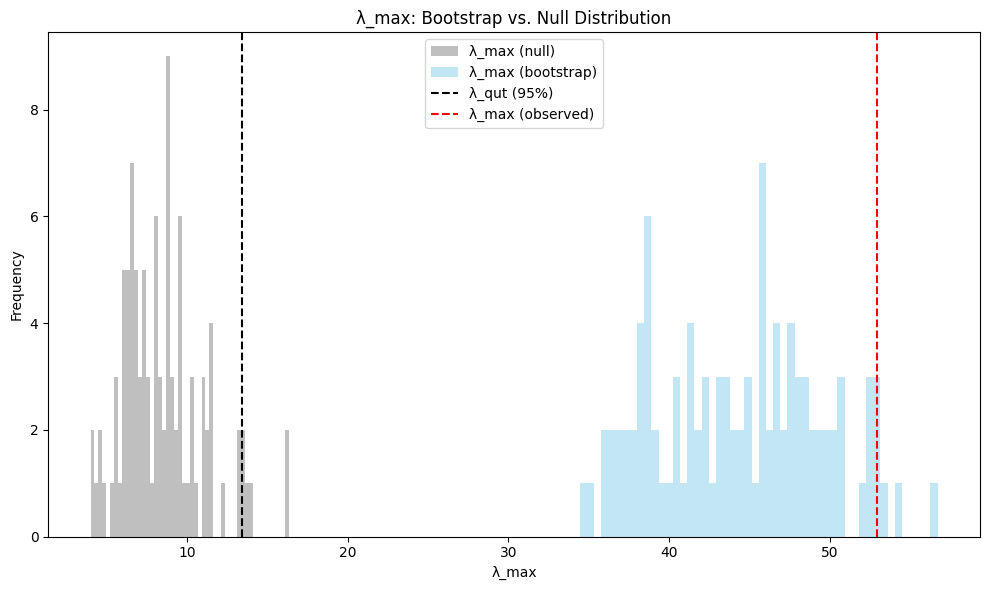

Plotting pointwise percentile maps at lambda = 13.4089


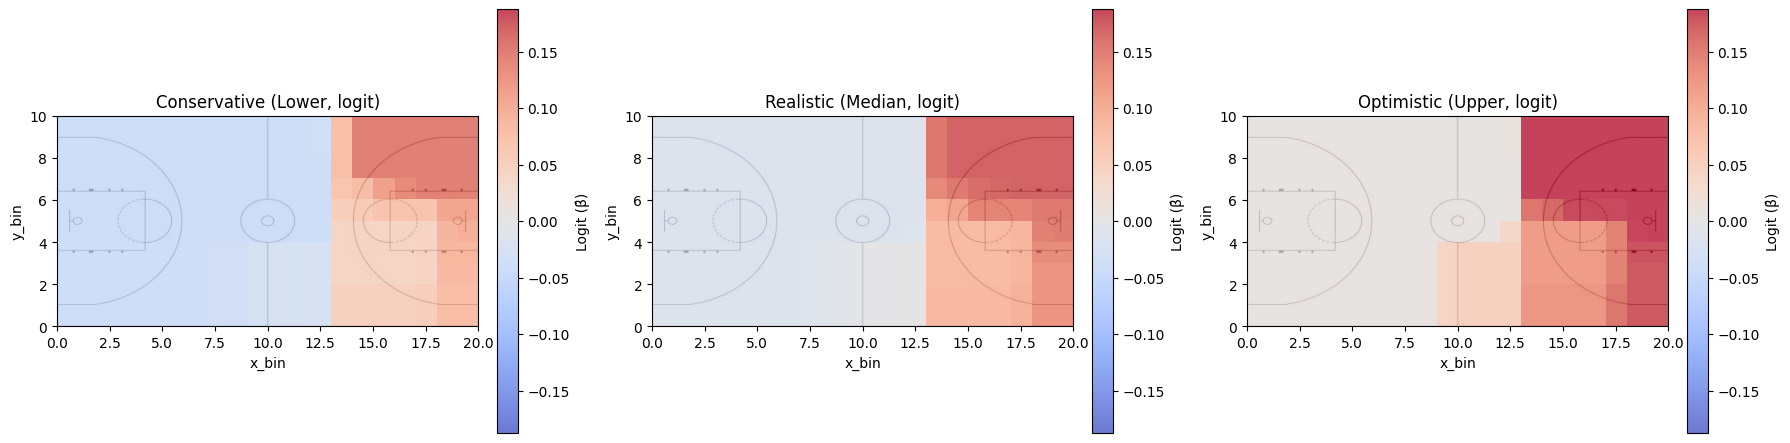

Completed in 56.43 seconds. Pointwise heatmaps were displayed and retained.

PLAN ROW 5/12 | reference__full_game__samples_per_possession__250
Profile/scenario: reference / full_game
Source construction: 5 units x 92 possessions = 460 distinct source possessions
Sweep value: samples_per_possession = 250
Bootstrap design: 100 replicates x 1,000 possessions x 250 tracking rows
Rows per bootstrap: 250,000
Estimated resampled rows across replicates: 25,000,000
Action: run QUT/bootstrap analysis and generate requested outputs.

=== Processing single ===


Processing Bootstrap Datasets:   0%|          | 0/100 [00:00<?, ?it/s]

Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 13.5800
λ_max (data): 54.5003


Processing Bootstrap Datasets: 100%|██████████| 100/100 [00:56<00:00,  1.76it/s]

λ_qut (95th percentile null): 13.5800
λ_max (observed): 54.5003
95% CI for λ_max (bootstrap): [36.8712, 55.1829]
Empirical p-value (λ_max > λ_qut): 0.0000


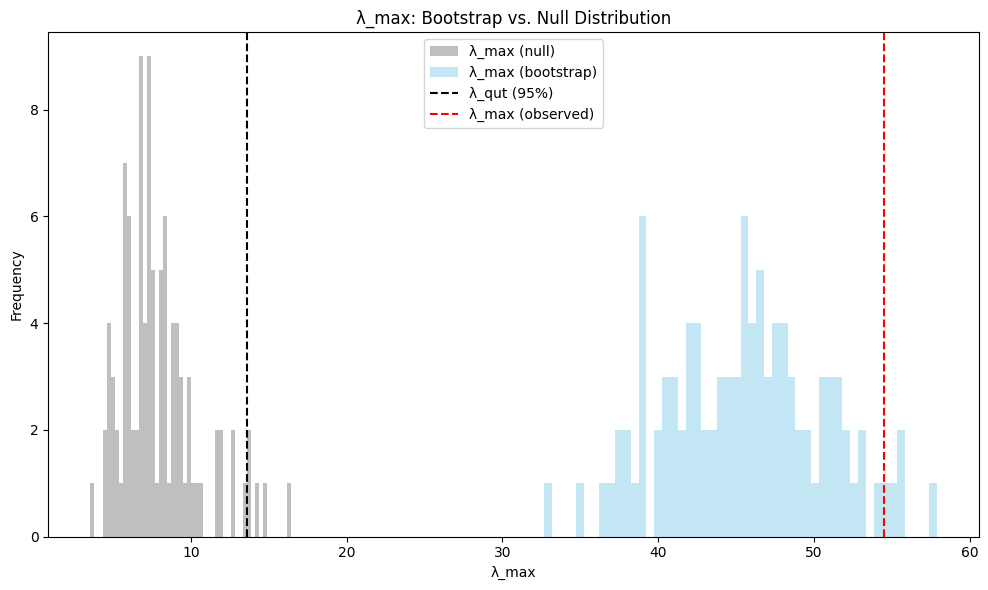

Plotting pointwise percentile maps at lambda = 13.5800


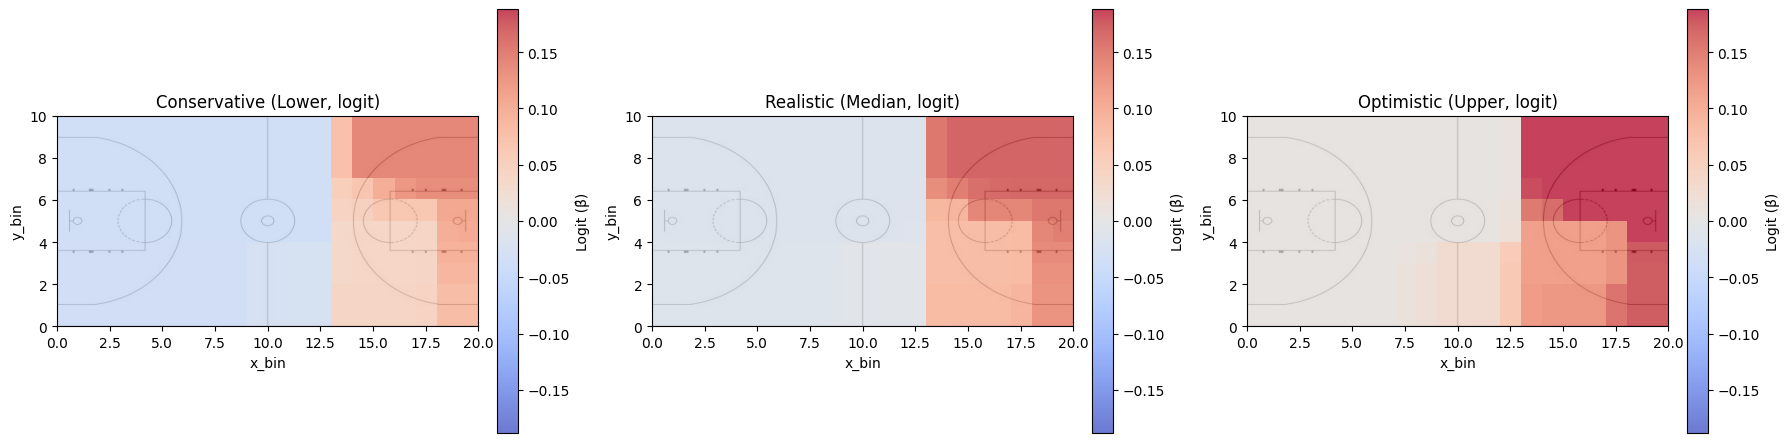

Completed in 57.27 seconds. Pointwise heatmaps were displayed and retained.

PLAN ROW 6/12 | reference__full_game__possessions_per_bootstrap__100
Profile/scenario: reference / full_game
Source construction: 5 units x 92 possessions = 460 distinct source possessions
Sweep value: possessions_per_bootstrap = 100
Bootstrap design: 100 replicates x 100 possessions x 200 tracking rows
Rows per bootstrap: 20,000
Estimated resampled rows across replicates: 2,000,000
Action: run QUT/bootstrap analysis and generate requested outputs.

=== Processing single ===


Processing Bootstrap Datasets:   0%|          | 0/100 [00:00<?, ?it/s]

Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 4.5178
λ_max (data): 5.5625


Processing Bootstrap Datasets: 100%|██████████| 100/100 [00:29<00:00,  3.44it/s]

λ_qut (95th percentile null): 4.5178
λ_max (observed): 5.5625
95% CI for λ_max (bootstrap): [2.5439, 7.3062]
Empirical p-value (λ_max > λ_qut): 0.0100


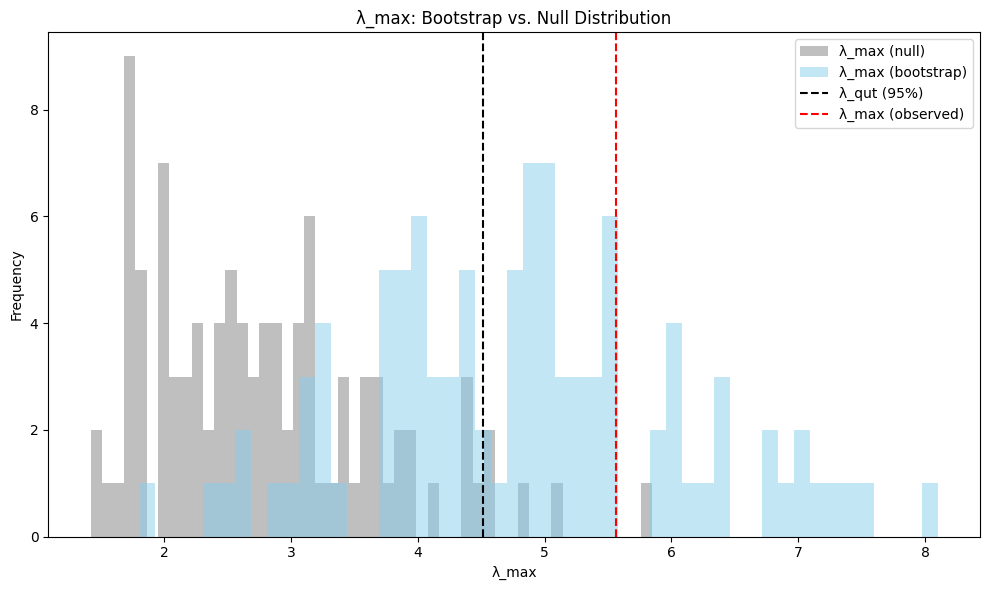

Plotting pointwise percentile maps at lambda = 4.5178


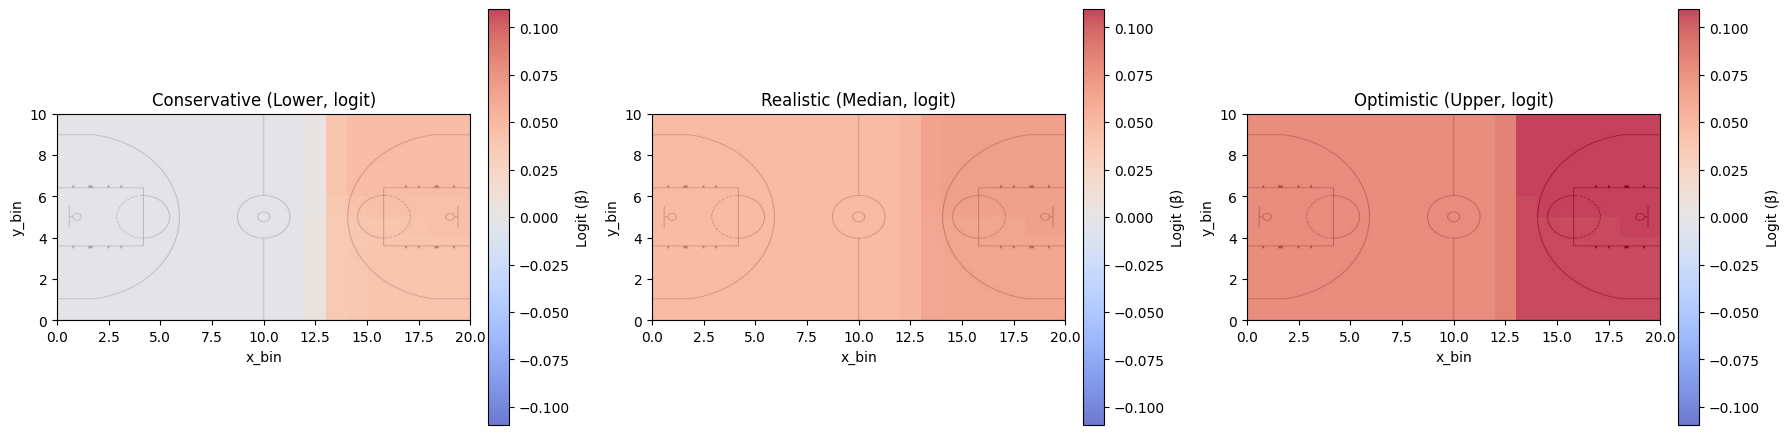

Completed in 29.44 seconds. Pointwise heatmaps were displayed and retained.

PLAN ROW 7/12 | reference__full_game__possessions_per_bootstrap__1000
Profile/scenario: reference / full_game
Source construction: 5 units x 92 possessions = 460 distinct source possessions
Sweep value: possessions_per_bootstrap = 1,000
Bootstrap design: 100 replicates x 1,000 possessions x 200 tracking rows
Rows per bootstrap: 200,000
Estimated resampled rows across replicates: 20,000,000
Action: reuse cached result for this identical configuration.

PLAN ROW 8/12 | reference__full_game__possessions_per_bootstrap__10000
Profile/scenario: reference / full_game
Source construction: 5 units x 92 possessions = 460 distinct source possessions
Sweep value: possessions_per_bootstrap = 10,000
Bootstrap design: 100 replicates x 10,000 possessions x 200 tracking rows
Rows per bootstrap: 2,000,000
Estimated resampled rows across replicates: 200,000,000
Action: run QUT/bootstrap analysis and generate requested outputs.



Processing Bootstrap Datasets:   0%|          | 0/100 [00:00<?, ?it/s]

Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 37.8440
λ_max (data): 450.2942


Processing Bootstrap Datasets: 100%|██████████| 100/100 [06:04<00:00,  3.64s/it]

λ_qut (95th percentile null): 37.8440
λ_max (observed): 450.2942
95% CI for λ_max (bootstrap): [418.8629, 473.4254]
Empirical p-value (λ_max > λ_qut): 0.0000


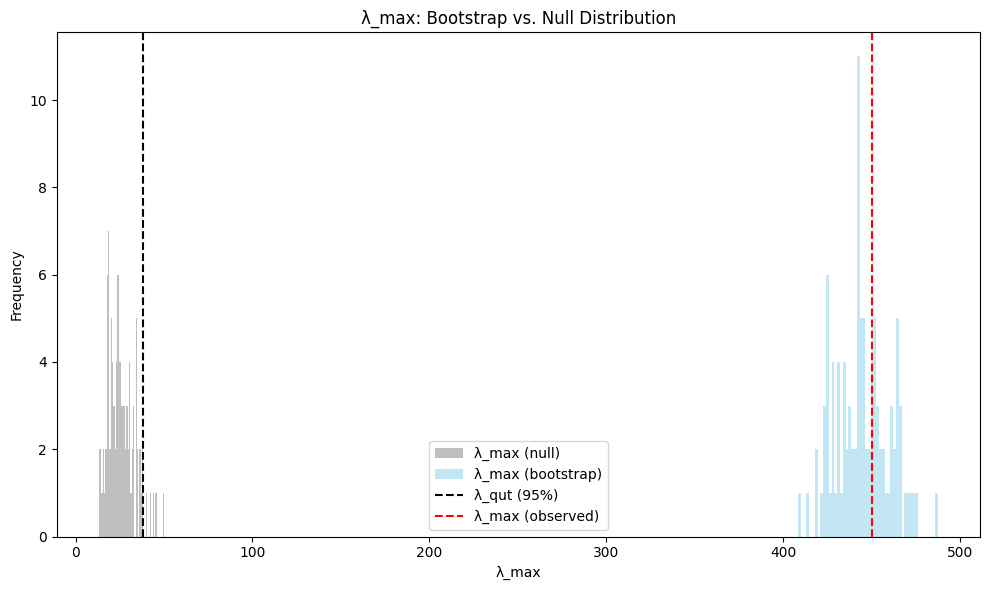

Plotting pointwise percentile maps at lambda = 37.8440


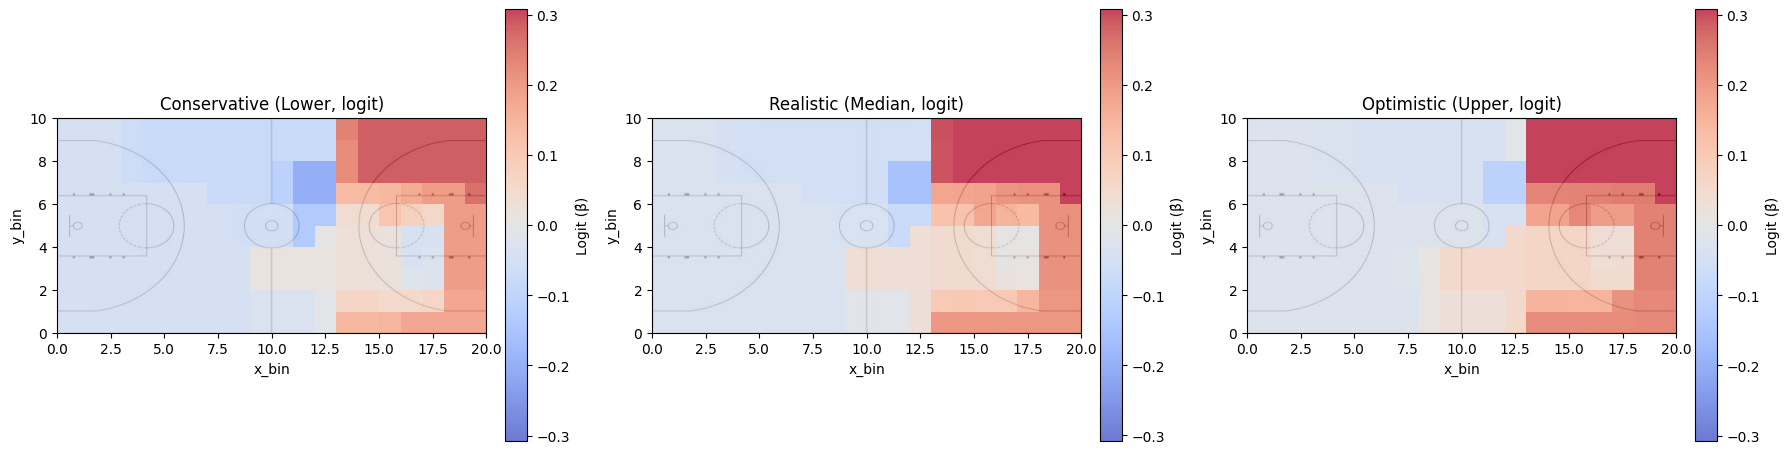

Completed in 364.62 seconds. Pointwise heatmaps were displayed and retained.

PLAN ROW 9/12 | reference__full_game__n_bootstraps__10
Profile/scenario: reference / full_game
Source construction: 5 units x 92 possessions = 460 distinct source possessions
Sweep value: n_bootstraps = 10
Bootstrap design: 10 replicates x 1,000 possessions x 200 tracking rows
Rows per bootstrap: 200,000
Estimated resampled rows across replicates: 2,000,000
Action: run QUT/bootstrap analysis and generate requested outputs.

=== Processing single ===


Processing Bootstrap Datasets:   0%|          | 0/10 [00:00<?, ?it/s]

Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 12.0086
λ_max (data): 52.9610


Processing Bootstrap Datasets: 100%|██████████| 10/10 [00:07<00:00,  1.34it/s]

λ_qut (95th percentile null): 12.0086
λ_max (observed): 52.9610
95% CI for λ_max (bootstrap): [37.6487, 52.2230]
Empirical p-value (λ_max > λ_qut): 0.0000


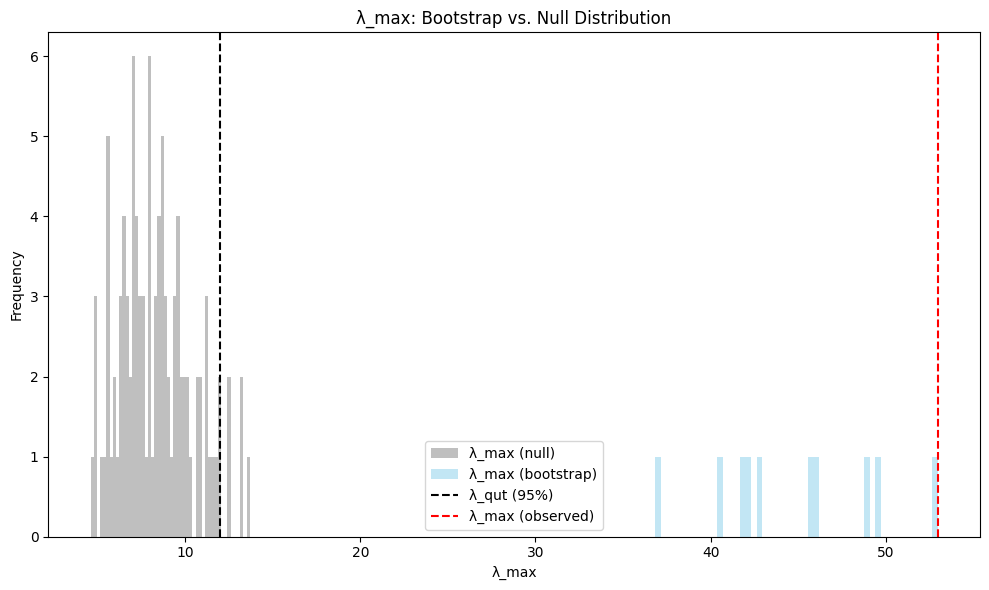

Plotting pointwise percentile maps at lambda = 12.0086


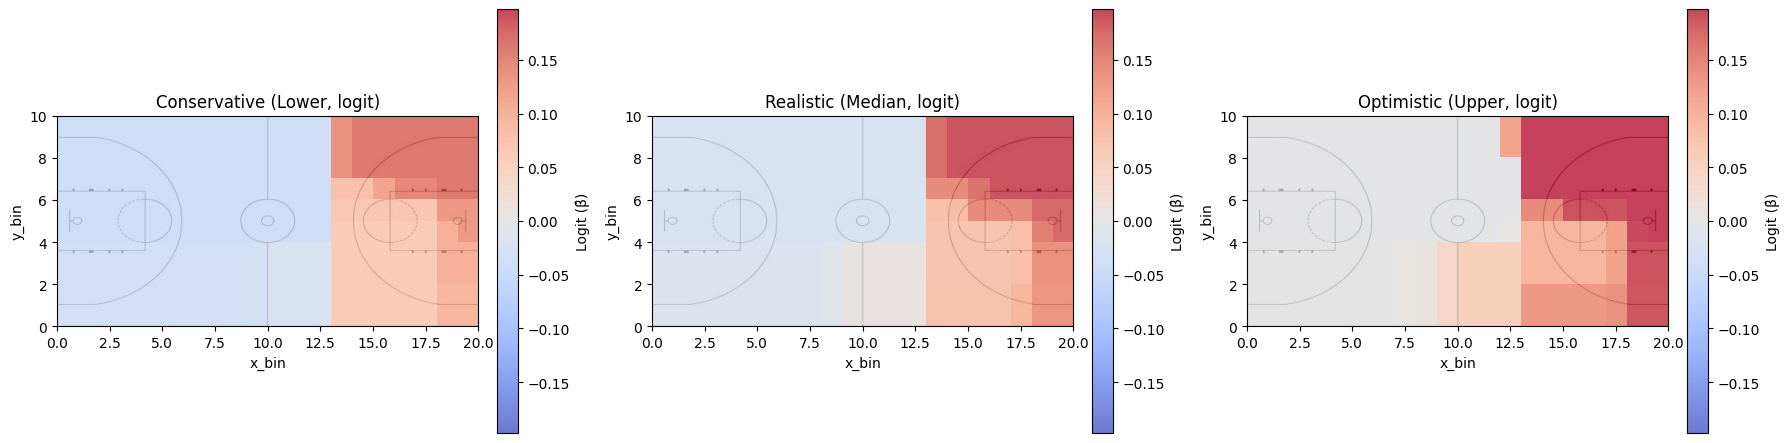

Completed in 7.82 seconds. Pointwise heatmaps were displayed and retained.

PLAN ROW 10/12 | reference__full_game__n_bootstraps__50
Profile/scenario: reference / full_game
Source construction: 5 units x 92 possessions = 460 distinct source possessions
Sweep value: n_bootstraps = 50
Bootstrap design: 50 replicates x 1,000 possessions x 200 tracking rows
Rows per bootstrap: 200,000
Estimated resampled rows across replicates: 10,000,000
Action: run QUT/bootstrap analysis and generate requested outputs.

=== Processing single ===


Processing Bootstrap Datasets:   0%|          | 0/50 [00:00<?, ?it/s]

Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 13.0663
λ_max (data): 52.9610


Processing Bootstrap Datasets: 100%|██████████| 50/50 [00:29<00:00,  1.72it/s]

λ_qut (95th percentile null): 13.0663
λ_max (observed): 52.9610
95% CI for λ_max (bootstrap): [36.0723, 52.9457]
Empirical p-value (λ_max > λ_qut): 0.0000


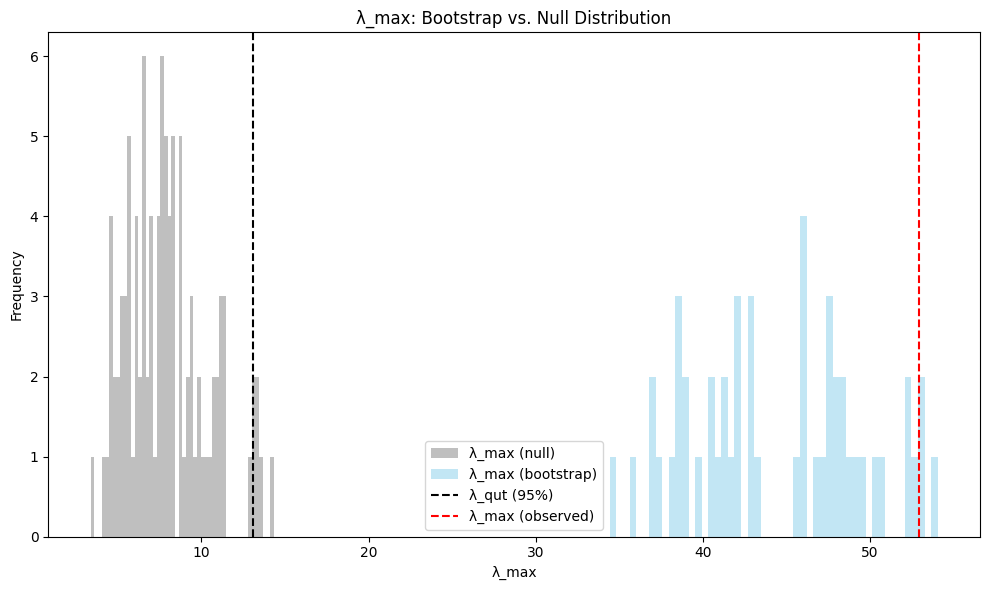

Plotting pointwise percentile maps at lambda = 13.0663


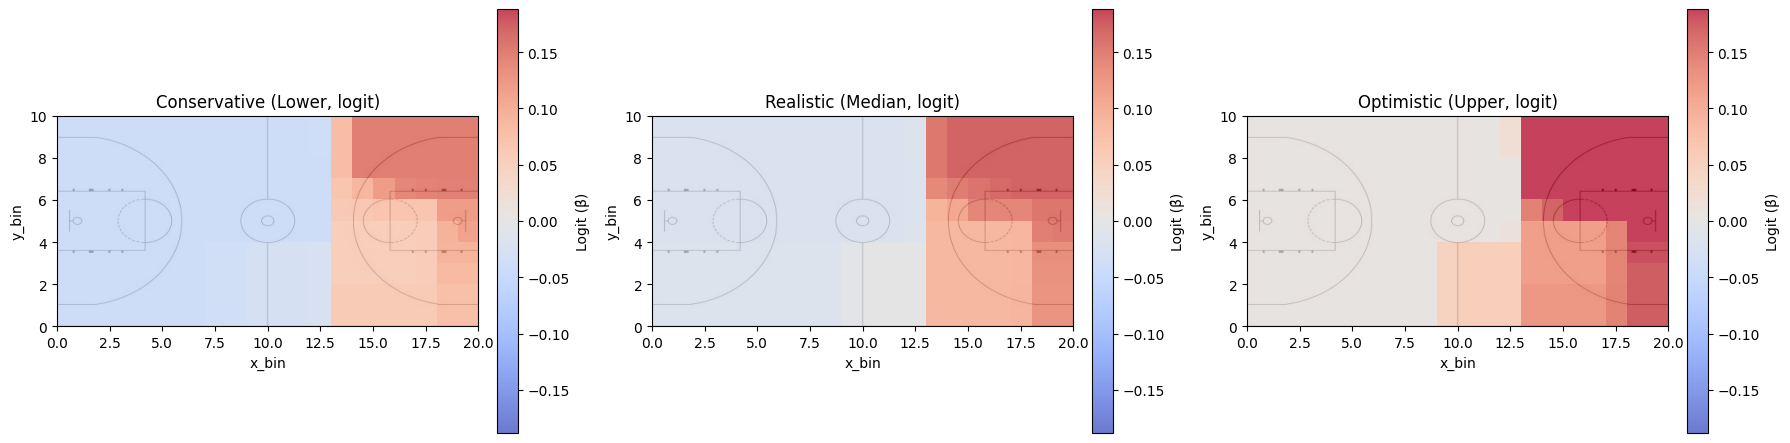

Completed in 29.47 seconds. Pointwise heatmaps were displayed and retained.

PLAN ROW 11/12 | reference__full_game__n_bootstraps__100
Profile/scenario: reference / full_game
Source construction: 5 units x 92 possessions = 460 distinct source possessions
Sweep value: n_bootstraps = 100
Bootstrap design: 100 replicates x 1,000 possessions x 200 tracking rows
Rows per bootstrap: 200,000
Estimated resampled rows across replicates: 20,000,000
Action: reuse cached result for this identical configuration.

PLAN ROW 12/12 | reference__full_game__n_bootstraps__500
Profile/scenario: reference / full_game
Source construction: 5 units x 92 possessions = 460 distinct source possessions
Sweep value: n_bootstraps = 500
Bootstrap design: 500 replicates x 1,000 possessions x 200 tracking rows
Rows per bootstrap: 200,000
Estimated resampled rows across replicates: 100,000,000
Action: run QUT/bootstrap analysis and generate requested outputs.

=== Processing single ===


Processing Bootstrap Datasets:   0%|          | 0/500 [00:00<?, ?it/s]

Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 12.6855
λ_max (data): 52.9610


Processing Bootstrap Datasets: 100%|██████████| 500/500 [04:30<00:00,  1.85it/s]

λ_qut (95th percentile null): 12.6855
λ_max (observed): 52.9610
95% CI for λ_max (bootstrap): [34.8240, 54.3161]
Empirical p-value (λ_max > λ_qut): 0.0000


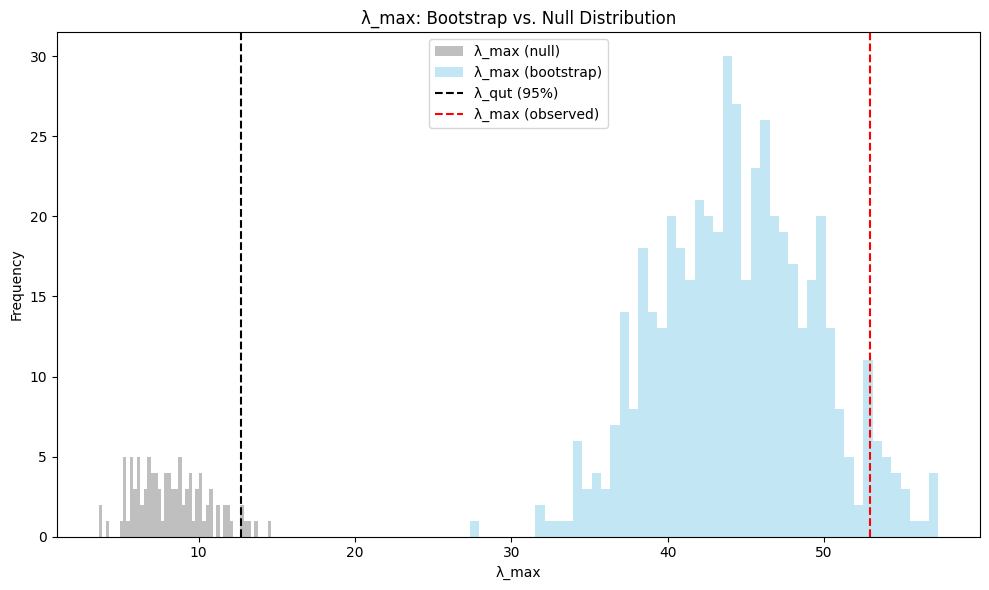

Plotting pointwise percentile maps at lambda = 12.6855


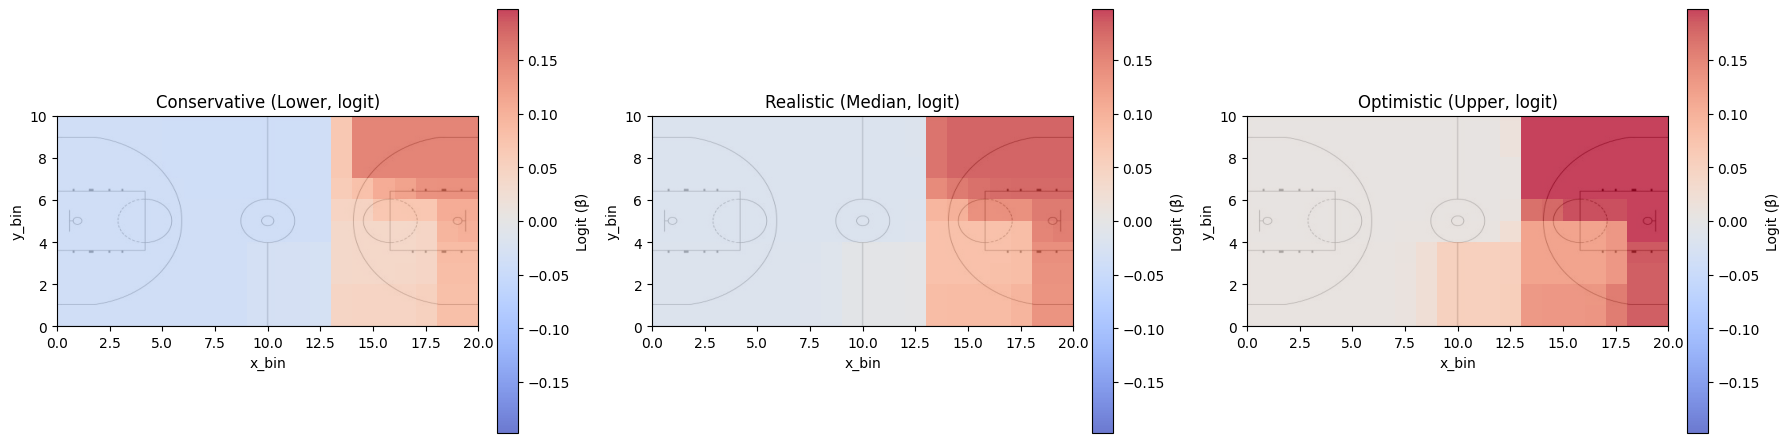

Completed in 270.51 seconds. Pointwise heatmaps were displayed and retained.


,run_id,profile,scenario,simulation_units,possessions_per_unit,simulated_possessions,parameter,value,samples_per_possession,possessions_per_bootstrap,...,status,reused_result,heatmap_status,elapsed_seconds,lambda_qut,lambda_max_obs,lambda_ci_low,lambda_ci_high,p_value,error
0,reference__full_game__samples_per_possession__50,reference,full_game,5,92,460,samples_per_possession,50,50,1000,...,ok,False,generated,47.903065,9.394344,43.171685,24.879038,42.013062,0.00,None
1,reference__full_game__samples_per_possession__100,reference,full_game,5,92,460,samples_per_possession,100,100,1000,...,ok,False,generated,51.263442,11.550464,48.649775,31.751026,48.546054,0.00,None
2,reference__full_game__samples_per_possession__150,reference,full_game,5,92,460,samples_per_possession,150,150,1000,...,ok,False,generated,54.962058,11.881704,51.995994,34.986874,52.156817,0.00,None
3,reference__full_game__samples_per_possession__200,reference,full_game,5,92,460,samples_per_possession,200,200,1000,...,ok,False,generated,56.434130,13.408943,52.961034,36.004290,53.274564,0.00,None
4,reference__full_game__samples_per_possession__250,reference,full_game,5,92,460,samples_per_possession,250,250,1000,...,ok,False,generated,57.273792,13.580024,54.500315,36.871240,55.182918,0.00,None
5,reference__full_game__possessions_per_bootstra...,reference,full_game,5,92,460,possessions_per_bootstrap,100,200,100,...,ok,False,generated,29.442305,4.517758,5.562487,2.543890,7.306164,0.01,None
6,reference__full_game__possessions_per_bootstra...,reference,full_game,5,92,460,possessions_per_bootstrap,1000,200,1000,...,ok,True,reused,0.000057,13.408943,52.961034,36.004290,53.274564,0.00,None
7,reference__full_game__possessions_per_bootstra...,reference,full_game,5,92,460,possessions_per_bootstrap,10000,200,10000,...,ok,False,generated,364.615450,37.844001,450.294201,418.862937,473.425359,0.00,None
8,reference__full_game__n_bootstraps__10,reference,full_game,5,92,460,n_bootstraps,10,200,1000,...,ok,False,generated,7.822378,12.008612,52.961034,37.648707,52.223007,0.00,None
9,reference__full_game__n_bootstraps__50,reference,full_game,5,92,460,n_bootstraps,50,200,1000,...,ok,False,generated,29.470379,13.066335,52.961034,36.072278,52.945741,0.00,None


In [25]:
from time import perf_counter


def run_incremental_bootstrap_experiments(
    scenario_inputs,
    experiment_plan,
    selected_profiles=None,
    selected_scenarios=None,
    selected_parameters=None,
    min_samples_required=50,
    mc_null=100,
    alpha=0.05,
    seed=42,
    show_progress=True,
    plot_pointwise_maps=True,
    plot_lambda_distributions=False,
    court_image_path="court.jpg",
    document_runs=True,
):
    """Run selected rows, document their settings, and optionally plot heatmaps."""
    plan = experiment_plan.copy()

    selections = {
        "profile": selected_profiles,
        "scenario": selected_scenarios,
        "parameter": selected_parameters,
    }
    for column, selected_values in selections.items():
        if selected_values is None:
            continue
        if isinstance(selected_values, str):
            selected_values = [selected_values]
        else:
            selected_values = list(selected_values)

        valid_values = set(experiment_plan[column].unique())
        unknown_values = set(selected_values).difference(valid_values)
        if unknown_values:
            raise ValueError(
                f"Unknown {column} selection(s): {sorted(unknown_values)}. "
                f"Valid values are: {sorted(valid_values)}."
            )
        plan = plan[plan[column].isin(selected_values)]
    if plan.empty:
        raise ValueError("No experiment rows remain after applying the selections.")

    configuration_cols = [
        "profile",
        "scenario",
        "n_bootstraps",
        "possessions_per_bootstrap",
        "samples_per_possession",
    ]
    unique_supported_runs = (
        plan[plan["possessions_per_bootstrap"] >= 2]
        .drop_duplicates(configuration_cols)
    )
    if document_runs:
        print("\nINCREMENTAL TV-LOGISTIC/QUT EXPERIMENT")
        print("-" * 80)
        print(f"Plan rows selected: {len(plan)}")
        print(f"Unique supported analyses: {len(unique_supported_runs)}")
        print(f"Profiles: {', '.join(map(str, plan['profile'].unique()))}")
        print(f"Scenarios: {', '.join(map(str, plan['scenario'].unique()))}")
        print("Trajectory control: each scenario uses one shared trajectory sample across profiles.")
        print(f"Source-possession eligibility threshold: {min_samples_required} tracking rows")
        print(f"Monte Carlo null simulations per unique analysis: {mc_null}")
        if plot_pointwise_maps:
            print("Heatmaps: enabled (lower, median, and upper pointwise logit maps).")
            print("Heatmaps require one additional TV-logistic fit per bootstrap replicate.")
        else:
            print("Heatmaps: disabled.")

    summary_rows = []
    raw_results = {}
    result_cache = {}

    for plan_index, row in enumerate(plan.itertuples(index=False), start=1):
        rows_per_bootstrap = row.possessions_per_bootstrap * row.samples_per_possession
        estimated_total_rows = rows_per_bootstrap * row.n_bootstraps
        settings_key = (
            row.profile,
            row.scenario,
            row.n_bootstraps,
            row.possessions_per_bootstrap,
            row.samples_per_possession,
        )
        unsupported_reason = None
        if row.possessions_per_bootstrap < 2:
            unsupported_reason = (
                "At least two possessions are required because the logistic QUT null "
                "must contain both outcome classes."
            )

        result = result_cache.get(settings_key)
        reused_result = result is not None
        started = perf_counter()
        error_message = unsupported_reason

        if document_runs:
            print("\n" + "=" * 80)
            print(f"PLAN ROW {plan_index}/{len(plan)} | {row.run_id}")
            print(f"Profile/scenario: {row.profile} / {row.scenario}")
            print(
                f"Source construction: {row.simulation_units:,} units x "
                f"{row.possessions_per_unit:,} possessions = "
                f"{row.simulated_possessions:,} distinct source possessions"
            )
            print(f"Sweep value: {row.parameter} = {row.value:,}")
            print(
                f"Bootstrap design: {row.n_bootstraps:,} replicates x "
                f"{row.possessions_per_bootstrap:,} possessions x "
                f"{row.samples_per_possession:,} tracking rows"
            )
            print(f"Rows per bootstrap: {rows_per_bootstrap:,}")
            print(f"Estimated resampled rows across replicates: {estimated_total_rows:,}")
            if estimated_total_rows >= 100_000_000:
                print("WARNING: high-workload configuration; expect substantially longer runtime.")
            if unsupported_reason is not None:
                print(f"Action: skipped - {unsupported_reason}")
            elif reused_result:
                print("Action: reuse cached result for this identical configuration.")
            else:
                print("Action: run QUT/bootstrap analysis and generate requested outputs.")

        if result is None and unsupported_reason is None:
            try:
                result = analyze_tv_logistic_single_game(
                    scenario_inputs[row.profile][row.scenario]["qut_input"],
                    game_id=None,
                    n_bootstraps=row.n_bootstraps,
                    n_possessions=row.possessions_per_bootstrap,
                    samples_per_possession=row.samples_per_possession,
                    min_samples_required=min_samples_required,
                    mc_null=mc_null,
                    alpha=alpha,
                    court_image_path=court_image_path,
                    show_progress=show_progress,
                    plot_pointwise_maps=plot_pointwise_maps,
                    plot_lambda_distributions=plot_lambda_distributions,
                    seed=seed,
                )
                result_cache[settings_key] = result
            except Exception as exc:
                error_message = f"{type(exc).__name__}: {exc}"
                if document_runs:
                    print(f"Action: failed - {error_message}")

        elapsed_seconds = perf_counter() - started
        if result is not None:
            raw_results[row.run_id] = result
            if document_runs and not reused_result:
                heatmap_note = (
                    " Pointwise heatmaps were displayed and retained."
                    if "pointwise" in result
                    else " Pointwise heatmaps were not requested."
                )
                print(f"Completed in {elapsed_seconds:.2f} seconds.{heatmap_note}")

        if result is not None and "pointwise" in result:
            heatmap_status = "reused" if reused_result else "generated"
        elif result is not None:
            heatmap_status = "disabled"
        else:
            heatmap_status = "not_available"

        summary_rows.append({
            "run_id": row.run_id,
            "profile": row.profile,
            "scenario": row.scenario,
            "simulation_units": row.simulation_units,
            "possessions_per_unit": row.possessions_per_unit,
            "simulated_possessions": row.simulated_possessions,
            "parameter": row.parameter,
            "value": row.value,
            "samples_per_possession": row.samples_per_possession,
            "possessions_per_bootstrap": row.possessions_per_bootstrap,
            "n_bootstraps": row.n_bootstraps,
            "rows_per_bootstrap": rows_per_bootstrap,
            "estimated_total_rows": estimated_total_rows,
            "status": (
                "ok" if result is not None
                else "unsupported" if unsupported_reason is not None
                else "failed"
            ),
            "reused_result": reused_result,
            "heatmap_status": heatmap_status,
            "elapsed_seconds": elapsed_seconds,
            "lambda_qut": np.nan if result is None else result["lambda_qut"],
            "lambda_max_obs": np.nan if result is None else result["lambda_max_obs"],
            "lambda_ci_low": np.nan if result is None else result["lambda_max_ci"][0],
            "lambda_ci_high": np.nan if result is None else result["lambda_max_ci"][1],
            "p_value": np.nan if result is None else result["p_value"],
            "error": error_message,
        })

    return pd.DataFrame(summary_rows), raw_results


# Start with one scenario or parameter group before enabling the entire plan.
RUN_INCREMENTAL_EXPERIMENTS = True
SELECTED_PROFILES = ["reference"]  # Example: ["reference", "perimeter"]
SELECTED_SCENARIOS = ["full_game"]  # Example: ["quarter"]
SELECTED_PARAMETERS = ["samples_per_possession", "possessions_per_bootstrap", "n_bootstraps"]  # Example: ["samples_per_possession"]
PLOT_INCREMENTAL_HEATMAPS = True
PLOT_INCREMENTAL_LAMBDA_DISTRIBUTIONS = True
DOCUMENT_INCREMENTAL_RUNS = True

if RUN_INCREMENTAL_EXPERIMENTS:
    incremental_experiment_summary, incremental_experiment_results = (
        run_incremental_bootstrap_experiments(
            simulation_scenarios,
            incremental_experiment_plan,
            selected_profiles=SELECTED_PROFILES,
            selected_scenarios=SELECTED_SCENARIOS,
            selected_parameters=SELECTED_PARAMETERS,
            min_samples_required=50,
            mc_null=100,
            seed=EXPERIMENT_SEED,
            plot_pointwise_maps=PLOT_INCREMENTAL_HEATMAPS,
            plot_lambda_distributions=PLOT_INCREMENTAL_LAMBDA_DISTRIBUTIONS,
            court_image_path="court.jpg",
            document_runs=DOCUMENT_INCREMENTAL_RUNS,
        )
    )
    display(incremental_experiment_summary)
else:
    print("Set RUN_INCREMENTAL_EXPERIMENTS = True after choosing the desired rows.")
    display(incremental_experiment_plan)